# Genome-RPKM And Selected-vOTU Strain Coverage Profiles

This uses the 10 prokaryotic genomes with the highest genome RPKM across all eligible host contigs and every genome with a vOTU block
selected in 09. Coverage profiles and activity calls are calculated for the 36 samples.


## Activity thresholds

A block is called active in a sample when it meets all PropagAtE-style criteria:
mean coverage >=1x, breadth >=0.50 at 1x, block:host mean-coverage ratio >=2,
Cohen's d >=0.70, after masking 150 bp at retained-contig ends. This is a
PropagAtE-style implementation based on the mapped-depth data.

## Host-contig filter

09 first keeps only bacterial-reference contigs at least 100 kb long with <80%
merged geNomad viral coverage. This notebook reads that explicit 09 eligibility
table, so its host layouts, coverage backgrounds, and activity calls use the
same reference-contig set as vOTU-block selection.


In [1]:
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
import math
import re
import gc

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.patches import Patch, Rectangle
from matplotlib.transforms import blended_transform_factory

plt.ioff()
plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "svg.fonttype": "none",
})


In [2]:
VIRAL_FRACTION_DIR = Path("/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION")
VIRAL_WORLD_DIR = VIRAL_FRACTION_DIR.parent
BACTERIAL_FRACTION_DIR = VIRAL_WORLD_DIR / "BACTERIAL_FRACTION"
MAPPING_DIR = VIRAL_FRACTION_DIR / "06_MAPPING"
REFERENCES_DIR = MAPPING_DIR / "REFERENCES"
SPLIT_DEPTH_DIR = REFERENCES_DIR / "STRAINS_IN_MICROBIAL_SPLIT"
FIGURES_TABLES_DIR = VIRAL_FRACTION_DIR / "FIGURES_AND_TABLES"

SAMPLING = "tot"
TOP_N_GENOMES = 10
INCLUDE_CURATED_VOTU_BLOCK_GENOMES = True
INCLUDE_BLAST_VOTU_BLOCKS = True
PLOT_WORKERS = 16
# Set this to True only when you want the large 36-sample per-genome coverage-profile SVGs.
# Activity calculations, tables, and compact summary figures still run when this is False.
MAKE_PER_GENOME_COVERAGE_PLOTS = True
SAVE_SVG = False
SAVE_PNG = True
# Rank the top genomes by a genome-level RPKM across all eligible host contigs.
# Within each sample this is a contig-length-weighted mean RPKM, equivalent to
# all eligible-contig reads / eligible-contig kb / library reads in millions.
# sum_genome_rpkm adds that genome RPKM across the 36 samples for ranking.
# single_sample_genome_rpkm instead ranks by the highest one-sample genome RPKM.
# The two *_contig_rpkm modes are retained only to inspect the former max-contig ranking.
RPKM_RANKING_MODE = "sum_genome_rpkm"
# These filters select only the extra top-RPKM genome profiles. They do not remove
# 09-selected vOTU-block genomes or alter any 10 PropagAtE-style activity calls.
TOP_RPKM_PROKARYOTIC_SUPERKINGDOMS = ["Bacteria", "Archaea"]
# A top-RPKM genome must reach >=10% breadth in at least one of the 36 samples.
# This rejects a genome whose high signal is confined to a narrow mapping hotspot.
TOP_RPKM_MIN_MAX_GENOME_BREADTH_PERCENT = 10.0
# Use the same bacterial-host contig screen as 09 before calculating host coverage.
# A contig must be >=100 kb and have <80% merged geNomad viral coverage.
MIN_REFERENCE_CONTIG_LENGTH = 100_000
MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION = 0.80
PLOT_BIN_SIZE = 1_000
Y_SCALE_MODE = "asinh"
LOG10_PSEUDOCOUNT = 1e-8
ASINH_COFACTOR = 1e-7
LINEAR_CLIP_QUANTILE = 0.995
USE_T_COVSTATS = False
EPSILON = 1e-12
SAVE_PER_GENOME_BINNED_PROFILES = False
SAVE_COMBINED_BINNED_PROFILES = False
# Keep the geNomad, curated-vOTU, and BLAST annotation tracks together at the top of each sample panel.
ANNOTATION_TRACK_TOP = 0.965
ANNOTATION_TRACK_HEIGHT = 0.045
ANNOTATION_TRACK_GAP = 0.012
# Show one compact metric line per curated vOTU block in the right plot margin.
# cov is mean block coverage, br is coverage breadth, FC is block:host fold change, and d is Cohen's d.
SHOW_CURATED_VOTU_METRICS = True
CURATED_VOTU_METRICS_FONT_SIZE = 4.8
CURATED_VOTU_BLOCK_LABEL_FONT_SIZE = 4.6
CURATED_VOTU_METRICS_LINE_HEIGHT = 0.09
PLOT_RIGHT_MARGIN_WITH_VOTU_METRICS = 0.79

VOTU_MIN_PIDENT = 90.0
VOTU_MIN_ALIGNMENT_LENGTH = 1_000
VOTU_MIN_QUERY_COVERAGE = 0.10
VOTU_MERGE_DISTANCE_BP = 1_000
VOTU_LABEL_LIMIT = 5
# PropagAtE-compatible curated-block activity thresholds.
VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE = 1.0
VOTU_REGION_ACTIVE_MIN_BREADTH = 0.50
VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE = 2.0
VOTU_REGION_ACTIVE_MIN_COHEN_D = 0.70
VOTU_REGION_EDGE_MASK_BP = 150
AVOTU_CATEGORY_ORDER = ["ubiquitous", "core", "common", "unique", "non_aVOTU"]
AVOTU_LEGEND_CATEGORY_ORDER = ["unique", "common", "core", "ubiquitous", "non_aVOTU"]
AVOTU_CATEGORY_COLORS = {
    "unique": "#6f6f6f",
    "common": "#cfcfcf",
    "core": "#36c99c",
    "ubiquitous": "#f4c400",
    "non_aVOTU": "#ffffff",
}
AVOTU_CATEGORY_LABELS = {
    "unique": "Low overlap/Unique avOTU",
    "common": "Common avOTU",
    "core": "Core avOTU",
    "ubiquitous": "Ubiquitous avOTU",
    "non_aVOTU": "curated vOTU, not in avOTU list",
}
GENOMAD_PROPHAGE_FACE_COLOR = "#ff3b30"
GENOMAD_PROPHAGE_EDGE_COLOR = "#b00020"

OUTPUT_PREFIX = f"top{TOP_N_GENOMES}_rpkm_plus_curated_votu_block_genomes"
OUTPUT_DIR = FIGURES_TABLES_DIR / f"strain_depth_profiles"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STRAIN_CONTIG_METADATA_PATH = (
    BACTERIAL_FRACTION_DIR
    / "MICROBIAL_GENOMES_PHYLLOVIR"
    / "strains_in_microbial_fraction_2018.seqtk_comp.with_source.tsv"
)
PROPHAGE_REGIONS_PATH = (
    BACTERIAL_FRACTION_DIR
    / "MICROBIAL_GENOMES_PHYLLOVIR"
    / "strains_in_microbial_fraction_2018_geNomad_virus_masked_regions.tsv"
)
STRAIN_METADATA_PATH = (
    BACTERIAL_FRACTION_DIR
    / "06_MAPPING"
    / "strains_in_microbial_fraction_metadata.csv"
)
VOTU_BLOCKS_PATH = (
    FIGURES_TABLES_DIR
    / "SUPPLEMENTARY"
    / "09_vOTU_block_test_set"
    / "09_vOTU_blocks_clustered_coverage_ranked.csv"
)
VOTU_BLAST_PATH = (
    BACTERIAL_FRACTION_DIR
    / "MICROBIAL_GENOMES_PHYLLOVIR"
    / "vOTUs_vs_strains_in_microbial_fraction_2018_blastout.tsv"
)
VOTU_PREVALENCE_METADATA_PATH = FIGURES_TABLES_DIR / "prevalence_metadata.csv"
ACTIVE_VOTU_LIST_PATH = FIGURES_TABLES_DIR / "active_vOTUs_threshold_1p5.csv"
SAMPLES_36 = [
    "vFL", "vOL", "vF23",
    "vN1", "vN2", "vN3",
    "vZ1", "vZ2", "vZ3",
    "vF1A", "vF2A", "vF3A",
    "vF1B", "vF2B", "vF3B",
    "vF1C", "vF2C", "vF3C",
    "vO1A", "vO2A", "vO3A",
    "vO1B", "vO2B", "vO3B",
    "vO1C", "vO2C", "vO3C",
    "vS1B", "vS2B", "vS3B",
    "vS1C", "vS2C", "vS3C",
    "vNWd", "vSWd", "vSEd",
]

SAMPLE_SORT = {sample: i for i, sample in enumerate(SAMPLES_36)}
CATEGORY_RANK = {category: i for i, category in enumerate(AVOTU_CATEGORY_ORDER)}
NON_AVOTU_CATEGORY = "non_aVOTU"
NON_AVOTU_CATEGORY_RANK = CATEGORY_RANK[NON_AVOTU_CATEGORY]


# 09 starts with shared clusters and retains direct vOTU-region placements with
# >=95% identity and >=85% reciprocal coverage. One region per vOTU is ranked by
# maximum bacterial-contig breadth across the 36 samples; breadth is not an 09
# eligibility criterion.
BLOCK_TEST_SET_OUTPUT_DIR = FIGURES_TABLES_DIR / "SUPPLEMENTARY" / "09_vOTU_block_test_set"
VOTU_BLOCKS_PATH = BLOCK_TEST_SET_OUTPUT_DIR / "09_vOTU_blocks_clustered_coverage_ranked.csv"
HOST_CONTIG_ELIGIBILITY_PATH = BLOCK_TEST_SET_OUTPUT_DIR / "09_host_contig_eligibility.csv"
SUPPLEMENTARY_PROFILE_ROOT = FIGURES_TABLES_DIR / "SUPPLEMENTARY" / "10_vOTU_block_activity"
OUTPUT_DIR = SUPPLEMENTARY_PROFILE_ROOT / "strain_depth_profiles"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PREFIX = f"10_votu_blocks_top{TOP_N_GENOMES}_rpkm_plus_votu_block_genomes"
HOST_CONTIG_ELIGIBILITY_OUTPUT_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_host_contig_eligibility.csv"
HOST_CONTIG_FILTER_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_host_contig_filter_summary.csv"
TOP_RPKM_FILTER_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_rpkm_filter_summary.csv"
TOP_RPKM_CANDIDATE_FLAGS_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_rpkm_candidate_flags.csv"


## Read reference metadata, taxonomy, prophage regions, and vOTU blocks


In [3]:
def pl_to_pandas(df: pl.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(df.to_dicts())


def safe_name(value: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value)).strip("_")


def sourmash_species_file_label(row) -> str:
    for field in ("species", "genus", "genome"):
        value = getattr(row, field, None)
        if value is None or pd.isna(value):
            continue
        value = str(value).strip()
        if value and value.lower() not in {"na", "nan", "none"}:
            return safe_name(value)
    return "unclassified"


def covstats_path(sample: str) -> Path:
    sample_part = f"{sample}_T" if USE_T_COVSTATS else sample
    return REFERENCES_DIR / f"bowtie2_strains_in_microbial_fraction_2018_{sample_part}_{SAMPLING}_covstats.txt"


def read_covstats(sample: str) -> pl.DataFrame:
    path = covstats_path(sample)
    if not path.exists():
        raise FileNotFoundError(path)

    covstats_columns = [
        "contig", "mean_depth", "length", "covered_bases", "read_count",
        "variance", "trimmed_mean", "rpkm",
    ]
    df = pl.read_csv(
        path,
        separator="\t",
        has_header=True,
        new_columns=covstats_columns,
        schema_overrides={
            "contig": pl.Utf8,
            "mean_depth": pl.Float64,
            "length": pl.Int64,
            "covered_bases": pl.Int64,
            "read_count": pl.Float64,
            "variance": pl.Float64,
            "trimmed_mean": pl.Float64,
            "rpkm": pl.Float64,
        },
    )
    if df.width != 8:
        raise ValueError(f"Expected 8 covstats columns in {path}, found {df.width}")

    return (
        df
        .with_columns(
            pl.lit(sample).alias("sample"),
            pl.col("contig").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"),
        )
        .select([
            "sample", "contig", "mean_depth", "length", "covered_bases",
            "read_count", "variance", "trimmed_mean", "rpkm",
        ])
    )


def read_strain_contig_metadata() -> pl.DataFrame:
    cols = [
        "seq", "seq_length", "A", "C", "G", "T", "#2", "#3", "#4",
        "#CpG", "#tv", "#ts", "#CpG-ts", "genome",
    ]
    all_contigs = (
        pl.read_csv(
            STRAIN_CONTIG_METADATA_PATH,
            separator="\t",
            has_header=False,
            new_columns=cols,
            schema_overrides={"seq": pl.Utf8, "seq_length": pl.Int64, "genome": pl.Utf8},
        )
        .with_columns(pl.col("seq").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"))
        .with_row_index("source_order")
        .select(["source_order", "seq", "seq_length", "genome"])
    )
    return all_contigs


def read_s02_host_contig_eligibility() -> pl.DataFrame:
    if not HOST_CONTIG_ELIGIBILITY_PATH.exists():
        raise FileNotFoundError(
            f"Missing {HOST_CONTIG_ELIGIBILITY_PATH}. Run 09 before 10."
        )

    required_columns = {
        "target_seq", "sequence_length", "genome", "geNomad_viral_bp",
        "geNomad_viral_fraction", "passes_length_filter",
        "passes_viral_content_filter", "eligible_for_votu_blocks",
        "filter_reason",
    }
    eligibility = pl.read_csv(HOST_CONTIG_ELIGIBILITY_PATH)
    missing_columns = required_columns.difference(eligibility.columns)
    if missing_columns:
        raise ValueError(
            "09 host-contig eligibility table is missing columns: "
            f"{sorted(missing_columns)}. Rerun 09."
        )

    eligibility = eligibility.with_columns(
        pl.col("target_seq").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"),
        pl.col("sequence_length").cast(pl.Int64),
        pl.col("genome").cast(pl.Utf8).str.strip_chars(),
        pl.col("geNomad_viral_bp").cast(pl.Int64),
        pl.col("geNomad_viral_fraction").cast(pl.Float64),
        pl.col("passes_length_filter").cast(pl.Boolean),
        pl.col("passes_viral_content_filter").cast(pl.Boolean),
        pl.col("eligible_for_votu_blocks").cast(pl.Boolean),
    )
    expected_eligibility = (
        (pl.col("sequence_length") >= MIN_REFERENCE_CONTIG_LENGTH)
        & (pl.col("geNomad_viral_fraction") < MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION)
    )
    inconsistent = eligibility.filter(
        pl.col("eligible_for_votu_blocks") != expected_eligibility
    )
    if not inconsistent.is_empty():
        raise ValueError(
            "The 09 host-contig eligibility table does not match the 10 100 kb/<80% "
            "filter. Rerun 09 before 10."
        )
    if eligibility["target_seq"].n_unique() != eligibility.height:
        raise ValueError("09 host-contig eligibility table has duplicate contig identifiers.")
    return eligibility


def read_strain_taxonomy_metadata() -> pl.DataFrame:
    taxonomy_cols = [
        "ident", "taxid", "superkingdom", "kingdom", "phylum", "class",
        "order", "family", "genus", "species", "strain", "genome_size",
    ]
    if not STRAIN_METADATA_PATH.exists():
        return pl.DataFrame(schema={"genome": pl.Utf8})
    return (
        pl.read_csv(
            STRAIN_METADATA_PATH,
            columns=taxonomy_cols,
            schema_overrides={
                "ident": pl.Utf8,
                "taxid": pl.Int64,
                "superkingdom": pl.Utf8,
                "kingdom": pl.Utf8,
                "phylum": pl.Utf8,
                "class": pl.Utf8,
                "order": pl.Utf8,
                "family": pl.Utf8,
                "genus": pl.Utf8,
                "species": pl.Utf8,
                "strain": pl.Utf8,
                "genome_size": pl.Int64,
            },
        )
        .rename({"ident": "genome"})
    )


def read_prophage_regions() -> pl.DataFrame:
    if not PROPHAGE_REGIONS_PATH.exists():
        return pl.DataFrame(schema={
            "target_seq": pl.Utf8,
            "start_1based": pl.Int64,
            "end_1based_inclusive": pl.Int64,
            "predicted_region_length": pl.Int64,
            "source_seq_name": pl.Utf8,
            "topology": pl.Utf8,
            "virus_score": pl.Float64,
            "n_hallmarks": pl.Int64,
            "taxonomy": pl.Utf8,
        })
    return (
        pl.read_csv(PROPHAGE_REGIONS_PATH, separator="\t", has_header=True)
        .with_columns(
            pl.col("target_seq").cast(pl.Utf8).str.strip_chars().str.replace_all("-", "_"),
            pl.col("start_1based").cast(pl.Int64),
            pl.col("end_1based_inclusive").cast(pl.Int64),
            pl.col("predicted_region_length").cast(pl.Int64),
            pl.col("virus_score").cast(pl.Float64),
            pl.col("n_hallmarks").cast(pl.Int64),
        )
    )


def read_all_covstats(samples: list[str]) -> pl.DataFrame:
    missing = [sample for sample in samples if not covstats_path(sample).exists()]
    if missing:
        raise FileNotFoundError(f"Missing covstats for samples: {missing}")
    return pl.concat([read_covstats(sample) for sample in samples], how="vertical")


In [4]:
def read_active_votu_list() -> pl.DataFrame:
    if not ACTIVE_VOTU_LIST_PATH.exists():
        return pl.DataFrame(schema={"vOTU": pl.Utf8})

    active = pl.read_csv(ACTIVE_VOTU_LIST_PATH)
    if "vOTU" not in active.columns:
        active = active.rename({active.columns[0]: "vOTU"})
    return active.select(pl.col("vOTU").cast(pl.Utf8).str.strip_chars()).unique()


def active_votu_values() -> list[str]:
    active = read_active_votu_list()
    return active["vOTU"].to_list() if not active.is_empty() else []


def _category_rank_expr(category_col: str = "avotu_category") -> pl.Expr:
    expr = pl.lit(NON_AVOTU_CATEGORY_RANK)
    for category, rank in reversed(CATEGORY_RANK.items()):
        expr = pl.when(pl.col(category_col) == category).then(pl.lit(rank)).otherwise(expr)
    return expr.cast(pl.Int64)


def _category_from_rank_expr(rank_col: str = "avotu_category_rank") -> pl.Expr:
    expr = pl.lit(NON_AVOTU_CATEGORY)
    for category, rank in reversed(CATEGORY_RANK.items()):
        expr = pl.when(pl.col(rank_col) == rank).then(pl.lit(category)).otherwise(expr)
    return expr


def read_votu_category_metadata() -> pl.DataFrame:
    if not VOTU_PREVALENCE_METADATA_PATH.exists():
        return pl.DataFrame(schema={"qseqid": pl.Utf8, "avotu_category": pl.Utf8, "avotu_category_rank": pl.Int64})

    categories = pl.read_csv(VOTU_PREVALENCE_METADATA_PATH)
    if not {"vOTU", "category"}.issubset(set(categories.columns)):
        return pl.DataFrame(schema={"qseqid": pl.Utf8, "avotu_category": pl.Utf8, "avotu_category_rank": pl.Int64})

    return (
        categories
        .select([
            pl.col("vOTU").cast(pl.Utf8).str.strip_chars().alias("qseqid"),
            pl.col("category").cast(pl.Utf8).str.strip_chars().str.to_lowercase().alias("avotu_category"),
        ])
        .filter(pl.col("qseqid").is_not_null() & (pl.col("qseqid") != ""))
        .filter(pl.col("avotu_category").is_in(AVOTU_CATEGORY_ORDER))
        .with_columns(_category_rank_expr("avotu_category").alias("avotu_category_rank"))
        .unique(subset=["qseqid"], keep="first")
        .sort(["avotu_category_rank", "qseqid"])
    )


def _with_votu_category_fields(records: pl.DataFrame) -> pl.DataFrame:
    category_metadata = read_votu_category_metadata()
    if records.is_empty():
        return records.with_columns(
            pl.lit(NON_AVOTU_CATEGORY).alias("avotu_category"),
            pl.lit(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64).alias("avotu_category_rank"),
        )
    return (
        records
        .join(category_metadata, on="qseqid", how="left")
        .with_columns(
            pl.col("avotu_category").fill_null(NON_AVOTU_CATEGORY),
            pl.col("avotu_category_rank").fill_null(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64),
        )
    )


def read_curated_votu_genome_annotations() -> pl.DataFrame:
    if not VOTU_BLOCKS_PATH.exists():
        return pl.DataFrame(schema={
            "genome": pl.Utf8,
            "n_curated_votu_records": pl.Int64,
            "n_curated_votus": pl.Int64,
            "has_active_votu_list": pl.Boolean,
            "avotu_category_rank": pl.Int64,
            "avotu_category": pl.Utf8,
        })

    active_values = active_votu_values()
    blocks = pl.read_csv(
        VOTU_BLOCKS_PATH,
        columns=["qseqid", "genome"],
        schema_overrides={"qseqid": pl.Utf8, "genome": pl.Utf8},
    )
    if blocks.is_empty():
        return pl.DataFrame(schema={
            "genome": pl.Utf8,
            "n_curated_votu_records": pl.Int64,
            "n_curated_votus": pl.Int64,
            "has_active_votu_list": pl.Boolean,
            "avotu_category_rank": pl.Int64,
            "avotu_category": pl.Utf8,
        })

    return (
        blocks
        .with_columns(
            pl.col("qseqid").cast(pl.Utf8).str.strip_chars(),
            pl.col("genome").cast(pl.Utf8).str.strip_chars(),
            pl.col("qseqid").is_in(active_values).alias("is_active_votu_list"),
        )
        .pipe(_with_votu_category_fields)
        .group_by("genome")
        .agg(
            pl.len().cast(pl.Int64).alias("n_curated_votu_records"),
            pl.col("qseqid").n_unique().cast(pl.Int64).alias("n_curated_votus"),
            pl.col("is_active_votu_list").any().alias("has_active_votu_list"),
            pl.col("avotu_category_rank").min().cast(pl.Int64).alias("avotu_category_rank"),
        )
        .with_columns(_category_from_rank_expr("avotu_category_rank").alias("avotu_category"))
        .sort(["avotu_category_rank", "genome"])
    )


def empty_votu_records() -> pl.DataFrame:
    return pl.DataFrame(schema={
        "genome": pl.Utf8,
        "qseqid": pl.Utf8,
        "sseqid": pl.Utf8,
        "target_start_1based": pl.Int64,
        "target_end_1based": pl.Int64,
        "concat_start": pl.Int64,
        "concat_end": pl.Int64,
        "alignment_length": pl.Int64,
        "query_coverage": pl.Float64,
        "target_coverage": pl.Float64,
        "pident": pl.Float64,
        "ani": pl.Float64,
        "is_active_votu": pl.Boolean,
        "votu_activity": pl.Utf8,
        "source": pl.Utf8,
        "source_label": pl.Utf8,
        "avotu_category": pl.Utf8,
        "avotu_category_rank": pl.Int64,
    })


def empty_votu_blocks() -> pl.DataFrame:
    return pl.DataFrame(schema={
        "genome": pl.Utf8,
        "target_seq": pl.Utf8,
        "block_start_1based": pl.Int64,
        "block_end_1based": pl.Int64,
        "concat_start": pl.Int64,
        "concat_end": pl.Int64,
        "n_records": pl.Int64,
        "n_votus": pl.Int64,
        "votus": pl.Utf8,
        "is_active_votu": pl.Boolean,
        "votu_activity": pl.Utf8,
        "source": pl.Utf8,
        "source_label": pl.Utf8,
        "sources": pl.Utf8,
        "avotu_category": pl.Utf8,
        "avotu_category_rank": pl.Int64,
        "max_pident": pl.Float64,
        "max_query_coverage": pl.Float64,
        "max_target_coverage": pl.Float64,
        "max_ani": pl.Float64,
        "total_aligned_bp": pl.Int64,
    })


def _activity_expr(active_values: list[str]) -> pl.Expr:
    return pl.when(pl.col("qseqid").is_in(active_values)).then(pl.lit(True)).otherwise(pl.lit(False))


def read_curated_votu_records_for_layouts(layouts: pl.DataFrame) -> pl.DataFrame:
    if not VOTU_BLOCKS_PATH.exists() or layouts.is_empty():
        return empty_votu_records()

    active_values = active_votu_values()
    target_layout = layouts.select([
        pl.col("genome").alias("layout_genome"),
        pl.col("seq").alias("sseqid"),
        pl.col("contig_offset"),
    ])

    blocks = pl.read_csv(
        VOTU_BLOCKS_PATH,
        schema_overrides={
            "qseqid": pl.Utf8,
            "genome": pl.Utf8,
            "sseqid": pl.Utf8,
            "start": pl.Int64,
            "end": pl.Int64,
            "len": pl.Int64,
            "pid": pl.Float64,
            "qcov": pl.Float64,
            "tcov": pl.Float64,
            "ANI": pl.Float64,
        },
    )
    if blocks.is_empty():
        return empty_votu_records()

    blocks = blocks.with_columns(
        pl.col("qseqid").cast(pl.Utf8).str.strip_chars(),
        pl.col("sseqid").cast(pl.Utf8).str.strip_chars(),
        pl.min_horizontal(pl.col("start"), pl.col("end")).alias("target_start_1based"),
        pl.max_horizontal(pl.col("start"), pl.col("end")).alias("target_end_1based"),
    )

    if "ACTIVE" in blocks.columns:
        blocks = blocks.with_columns(
            pl.col("ACTIVE").cast(pl.Utf8).str.to_lowercase().is_in(["true", "1", "yes", "y"]).alias("is_active_votu")
        )
    else:
        blocks = blocks.with_columns(_activity_expr(active_values).alias("is_active_votu"))

    return (
        blocks
        .join(target_layout, on="sseqid", how="inner")
        .with_columns(
            pl.col("layout_genome").alias("genome"),
            (pl.col("contig_offset") + pl.col("target_start_1based")).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("target_end_1based")).alias("concat_end"),
            (pl.col("qcov") / 100).alias("query_coverage"),
            (pl.col("tcov") / 100).alias("target_coverage"),
            pl.col("pid").alias("pident"),
            pl.col("ANI").alias("ani"),
            pl.col("len").alias("alignment_length"),
            pl.when(pl.col("is_active_votu")).then(pl.lit("active_list_yes")).otherwise(pl.lit("active_list_no")).alias("votu_activity"),
            pl.lit("curated_votu_block").alias("source"),
            pl.lit("curated vOTU block").alias("source_label"),
        )
        .select([col for col in empty_votu_records().columns if col not in {"avotu_category", "avotu_category_rank"}])
        .pipe(_with_votu_category_fields)
        .select(empty_votu_records().columns)
        .sort(["genome", "sseqid", "target_start_1based", "target_end_1based", "qseqid"])
    )


def read_blast_votu_records_for_layouts(layouts: pl.DataFrame) -> pl.DataFrame:
    if not INCLUDE_BLAST_VOTU_BLOCKS or not VOTU_BLAST_PATH.exists() or layouts.is_empty():
        return empty_votu_records()

    target_layout = layouts.select([
        pl.col("genome").alias("layout_genome"),
        pl.col("seq").alias("sseqid"),
        pl.col("contig_offset"),
    ])

    blast_cols = [
        "qseqid", "sseqid", "salltitles", "qstart", "qend", "sstart", "send",
        "qlen", "slen", "mismatch", "evalue", "alignment_length", "pident",
    ]
    hits = pl.read_csv(
        VOTU_BLAST_PATH,
        separator="	",
        has_header=False,
        new_columns=blast_cols,
        schema_overrides={
            "qseqid": pl.Utf8,
            "sseqid": pl.Utf8,
            "salltitles": pl.Utf8,
            "qstart": pl.Int64,
            "qend": pl.Int64,
            "sstart": pl.Int64,
            "send": pl.Int64,
            "qlen": pl.Int64,
            "slen": pl.Int64,
            "mismatch": pl.Int64,
            "evalue": pl.Float64,
            "alignment_length": pl.Int64,
            "pident": pl.Float64,
        },
    )

    return (
        hits
        .join(target_layout, on="sseqid", how="inner")
        .with_columns(
            pl.col("layout_genome").alias("genome"),
            pl.min_horizontal(pl.col("sstart"), pl.col("send")).alias("target_start_1based"),
            pl.max_horizontal(pl.col("sstart"), pl.col("send")).alias("target_end_1based"),
            (pl.col("alignment_length") / pl.col("qlen")).alias("query_coverage"),
            (pl.col("alignment_length") / pl.col("slen")).alias("target_coverage"),
            pl.lit(False).alias("is_active_votu"),
        )
        .filter(
            (pl.col("pident") >= VOTU_MIN_PIDENT)
            & (pl.col("alignment_length") >= VOTU_MIN_ALIGNMENT_LENGTH)
            & (pl.col("query_coverage") >= VOTU_MIN_QUERY_COVERAGE)
        )
        .with_columns(
            (pl.col("contig_offset") + pl.col("target_start_1based")).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("target_end_1based")).alias("concat_end"),
            pl.lit("not_applicable").alias("votu_activity"),
            pl.lit(None, dtype=pl.Float64).alias("ani"),
            pl.lit("blast_votu_block").alias("source"),
            pl.lit("BLAST vOTU block").alias("source_label"),
            pl.lit(NON_AVOTU_CATEGORY).alias("avotu_category"),
            pl.lit(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64).alias("avotu_category_rank"),
        )
        .select(empty_votu_records().columns)
        .sort(["genome", "sseqid", "target_start_1based", "target_end_1based", "qseqid"])
    )


def read_votu_records_for_layouts(layouts: pl.DataFrame) -> pl.DataFrame:
    records = [
        read_curated_votu_records_for_layouts(layouts),
        read_blast_votu_records_for_layouts(layouts),
    ]
    records = [df for df in records if not df.is_empty()]
    if not records:
        return empty_votu_records()
    return pl.concat(records, how="vertical").sort([
        "genome", "sseqid", "source", "is_active_votu",
        "target_start_1based", "target_end_1based", "qseqid",
    ])


def merge_votu_records(records: pl.DataFrame) -> pl.DataFrame:
    if records.is_empty():
        return empty_votu_blocks()

    rows = []
    records_pd = pl_to_pandas(records).sort_values([
        "genome", "sseqid", "source", "is_active_votu", "target_start_1based", "target_end_1based", "qseqid"
    ])

    group_cols = ["genome", "sseqid", "source", "source_label", "is_active_votu"]
    for (genome, target_seq, source, source_label, is_active), group in records_pd.groupby(group_cols, sort=False):
        current = None
        for record in group.itertuples(index=False):
            if current is None or record.target_start_1based > current["block_end_1based"] + VOTU_MERGE_DISTANCE_BP:
                if current is not None:
                    rows.append(current)
                current = {
                    "genome": genome,
                    "target_seq": target_seq,
                    "block_start_1based": int(record.target_start_1based),
                    "block_end_1based": int(record.target_end_1based),
                    "concat_start": int(record.concat_start),
                    "concat_end": int(record.concat_end),
                    "n_records": 1,
                    "votus_set": {record.qseqid},
                    "sources_set": {record.source},
                    "category_ranks": [int(record.avotu_category_rank) if pd.notna(record.avotu_category_rank) else NON_AVOTU_CATEGORY_RANK],
                    "is_active_votu": bool(is_active),
                    "votu_activity": "active_list_yes" if bool(is_active) else ("not_applicable" if source == "blast_votu_block" else "active_list_no"),
                    "source": source,
                    "source_label": source_label,
                    "max_pident": float(record.pident) if pd.notna(record.pident) else np.nan,
                    "max_query_coverage": float(record.query_coverage) if pd.notna(record.query_coverage) else np.nan,
                    "max_target_coverage": float(record.target_coverage) if pd.notna(record.target_coverage) else np.nan,
                    "max_ani": float(record.ani) if pd.notna(record.ani) else np.nan,
                    "total_aligned_bp": int(record.alignment_length) if pd.notna(record.alignment_length) else 0,
                }
            else:
                current["block_end_1based"] = max(current["block_end_1based"], int(record.target_end_1based))
                current["concat_end"] = max(current["concat_end"], int(record.concat_end))
                current["n_records"] += 1
                current["votus_set"].add(record.qseqid)
                current["sources_set"].add(record.source)
                current["category_ranks"].append(int(record.avotu_category_rank) if pd.notna(record.avotu_category_rank) else NON_AVOTU_CATEGORY_RANK)
                if pd.notna(record.pident):
                    current["max_pident"] = np.nanmax([current["max_pident"], float(record.pident)])
                if pd.notna(record.query_coverage):
                    current["max_query_coverage"] = np.nanmax([current["max_query_coverage"], float(record.query_coverage)])
                if pd.notna(record.target_coverage):
                    current["max_target_coverage"] = np.nanmax([current["max_target_coverage"], float(record.target_coverage)])
                if pd.notna(record.ani):
                    current["max_ani"] = np.nanmax([current["max_ani"], float(record.ani)])
                if pd.notna(record.alignment_length):
                    current["total_aligned_bp"] += int(record.alignment_length)
        if current is not None:
            rows.append(current)

    for row in rows:
        votus = sorted(row.pop("votus_set"))
        sources = sorted(row.pop("sources_set"))
        category_ranks = row.pop("category_ranks")
        category_rank = min(category_ranks) if category_ranks else NON_AVOTU_CATEGORY_RANK
        row["avotu_category_rank"] = int(category_rank)
        row["avotu_category"] = AVOTU_CATEGORY_ORDER[int(category_rank)] if int(category_rank) < len(AVOTU_CATEGORY_ORDER) else NON_AVOTU_CATEGORY
        row["n_votus"] = len(votus)
        row["sources"] = ", ".join(sources)
        if len(votus) > VOTU_LABEL_LIMIT:
            row["votus"] = ", ".join(votus[:VOTU_LABEL_LIMIT]) + f", +{len(votus) - VOTU_LABEL_LIMIT} more"
        else:
            row["votus"] = ", ".join(votus)

    return pl.DataFrame(rows).select(empty_votu_blocks().columns)


In [5]:
contig_metadata_all = read_strain_contig_metadata()
host_contig_eligibility = read_s02_host_contig_eligibility()

# Attach 09's explicit eligibility result to the reference layout. This keeps
# the activity background identical to the host-contig set used to make blocks.
host_contig_fields = [
    "target_seq", "sequence_length", "geNomad_viral_bp",
    "geNomad_viral_fraction", "passes_length_filter",
    "passes_viral_content_filter", "eligible_for_votu_blocks",
    "filter_reason",
]
contig_metadata_with_eligibility = contig_metadata_all.join(
    host_contig_eligibility.select(host_contig_fields).rename({
        "target_seq": "seq",
        "sequence_length": "s02_sequence_length",
    }),
    on="seq",
    how="left",
)
if contig_metadata_with_eligibility["eligible_for_votu_blocks"].null_count():
    raise ValueError("Some reference contigs are absent from the 09 eligibility table.")
if contig_metadata_with_eligibility.filter(
    pl.col("seq_length") != pl.col("s02_sequence_length")
).height:
    raise ValueError("Reference-contig lengths disagree between 09 and 10. Rerun 09.")

contig_metadata = (
    contig_metadata_with_eligibility
    .filter(pl.col("eligible_for_votu_blocks"))
    .drop("s02_sequence_length")
)

host_contig_filter_summary_frames = []
for step, frame in [
    ("All strain-reference contigs", contig_metadata_with_eligibility),
    (f"Contigs >= {MIN_REFERENCE_CONTIG_LENGTH:,} bp", contig_metadata_with_eligibility.filter(pl.col("passes_length_filter"))),
    (
        f">= {MIN_REFERENCE_CONTIG_LENGTH:,} bp excluded at >= {MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION:.0%} geNomad viral coverage",
        contig_metadata_with_eligibility.filter(pl.col("passes_length_filter") & ~pl.col("passes_viral_content_filter")),
    ),
    (
        f"Eligible: >= {MIN_REFERENCE_CONTIG_LENGTH:,} bp and < {MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION:.0%} geNomad viral coverage",
        contig_metadata,
    ),
]:
    host_contig_filter_summary_frames.append(frame.select(
        pl.lit(step).alias("step"),
        pl.len().alias("n_contigs"),
        pl.col("genome").n_unique().alias("n_genomes"),
        pl.col("seq_length").sum().alias("total_bp"),
    ))
host_contig_filter_summary = pl.concat(host_contig_filter_summary_frames, how="vertical")
contig_metadata_with_eligibility.write_csv(HOST_CONTIG_ELIGIBILITY_OUTPUT_PATH)
host_contig_filter_summary.write_csv(HOST_CONTIG_FILTER_SUMMARY_PATH)
display(host_contig_filter_summary)

strain_taxonomy = read_strain_taxonomy_metadata()
prophage_regions = read_prophage_regions()
all_covstats = read_all_covstats(SAMPLES_36)

curated_votu_genome_annotations_all = read_curated_votu_genome_annotations()
curated_votu_genome_annotations = (
    curated_votu_genome_annotations_all
    .join(contig_metadata.select("genome").unique(), on="genome", how="inner")
    if INCLUDE_CURATED_VOTU_BLOCK_GENOMES
    else pl.DataFrame(schema={
        "genome": pl.Utf8,
        "n_curated_votu_records": pl.Int64,
        "n_curated_votus": pl.Int64,
        "has_active_votu_list": pl.Boolean,
        "avotu_category_rank": pl.Int64,
        "avotu_category": pl.Utf8,
    })
)

taxonomy_lookup = pl_to_pandas(strain_taxonomy).set_index("genome").to_dict("index") if not strain_taxonomy.is_empty() else {}

covstats_with_genome = (
    all_covstats
    .join(contig_metadata.select(["seq", "genome"]), left_on="contig", right_on="seq", how="inner")
)

ignored_covstats_rows = all_covstats.height - covstats_with_genome.height
ignored_short_reference_contigs = contig_metadata_with_eligibility.filter(
    ~pl.col("passes_length_filter")
).height
ignored_viral_reference_contigs = contig_metadata_with_eligibility.filter(
    pl.col("passes_length_filter") & ~pl.col("passes_viral_content_filter")
).height
print(f"Reference contigs ignored because length < {MIN_REFERENCE_CONTIG_LENGTH:,} bp: {ignored_short_reference_contigs:,}")
print(
    f"Reference contigs ignored because geNomad viral coverage >= {MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION:.0%}: "
    f"{ignored_viral_reference_contigs:,}"
)
print(f"Covstats rows ignored by the host-contig filter: {ignored_covstats_rows:,}")
print(f"Curated vOTU-block genomes with eligible host contigs: {curated_votu_genome_annotations.height:,}")

# Each contig RPKM has the same per-sample library denominator. A length-weighted
# mean therefore gives a genome RPKM from every contig that passed the 09 host filter.
genome_sample_metrics = (
    covstats_with_genome
    .group_by(["sample", "genome"])
    .agg(
        pl.col("length").sum().alias("genome_length_from_covstats"),
        pl.col("covered_bases").sum().alias("genome_covered_bases"),
        pl.col("read_count").sum().alias("genome_read_count"),
        pl.len().alias("n_eligible_contigs"),
        pl.col("rpkm").max().alias("max_rpkm"),
        pl.col("rpkm").sum().alias("sum_contig_rpkm"),
        ((pl.col("rpkm") * pl.col("length")).sum() / pl.col("length").sum()).alias("genome_rpkm"),
        ((pl.col("mean_depth") * pl.col("length")).sum() / pl.col("length").sum()).alias("weighted_mean_depth"),
    )
    .with_columns(
        (pl.col("genome_covered_bases") * 100 / pl.col("genome_length_from_covstats")).alias("genome_covered_percentage")
    )
)

top_genome_summary = (
    genome_sample_metrics
    .group_by("genome")
    .agg(
        pl.col("genome_rpkm").sum().alias("total_genome_rpkm"),
        pl.col("genome_rpkm").max().alias("highest_sample_genome_rpkm"),
        pl.col("genome_length_from_covstats").first().alias("eligible_genome_length_bp"),
        pl.col("n_eligible_contigs").first().alias("n_eligible_contigs"),
        pl.col("max_rpkm").sum().alias("total_sample_max_rpkm"),
        pl.col("max_rpkm").max().alias("highest_sample_max_rpkm"),
        pl.col("sum_contig_rpkm").sum().alias("total_contig_rpkm"),
        pl.col("genome_read_count").sum().alias("total_genome_read_count"),
        (pl.col("genome_read_count") > 0).sum().alias("n_samples_with_reads"),
        pl.col("genome_covered_percentage").mean().alias("mean_genome_covered_percentage"),
        pl.col("genome_covered_percentage").max().alias("max_genome_covered_percentage"),
    )
    .join(strain_taxonomy, on="genome", how="left")
)

if RPKM_RANKING_MODE == "sum_genome_rpkm":
    rank_col = "total_genome_rpkm"
elif RPKM_RANKING_MODE == "single_sample_genome_rpkm":
    rank_col = "highest_sample_genome_rpkm"
elif RPKM_RANKING_MODE == "sum_sample_max_contig_rpkm":
    rank_col = "total_sample_max_rpkm"
elif RPKM_RANKING_MODE == "single_sample_max_contig_rpkm":
    rank_col = "highest_sample_max_rpkm"
else:
    raise ValueError("RPKM_RANKING_MODE must be one of: sum_genome_rpkm, single_sample_genome_rpkm, sum_sample_max_contig_rpkm, single_sample_max_contig_rpkm")

# Filter only the extra top-RPKM display genomes. Curated vOTU-block genomes are
# added below regardless of taxonomy or host-genome breadth, so the activity test set is unchanged.
top_rpkm_candidate_flags = top_genome_summary.with_columns(
    pl.col("superkingdom").is_in(TOP_RPKM_PROKARYOTIC_SUPERKINGDOMS).fill_null(False).alias("is_prokaryote"),
    (pl.col("max_genome_covered_percentage") >= TOP_RPKM_MIN_MAX_GENOME_BREADTH_PERCENT).alias("passes_top_rpkm_breadth_filter"),
)

top_rpkm_filter_summary = pl.concat([
    top_rpkm_candidate_flags.select(pl.lit("All eligible-reference genomes").alias("step"), pl.len().alias("n_genomes")),
    top_rpkm_candidate_flags.filter(pl.col("is_prokaryote")).select(
        pl.lit("Prokaryotes (Bacteria or Archaea)").alias("step"), pl.len().alias("n_genomes")
    ),
    top_rpkm_candidate_flags.filter(
        pl.col("is_prokaryote") & pl.col("passes_top_rpkm_breadth_filter")
    ).select(
        pl.lit(f"Prokaryotes with maximum genome breadth >= {TOP_RPKM_MIN_MAX_GENOME_BREADTH_PERCENT:g}%").alias("step"),
        pl.len().alias("n_genomes"),
    ),
])
top_rpkm_filter_summary.write_csv(TOP_RPKM_FILTER_SUMMARY_PATH)
top_rpkm_candidate_flags.write_csv(TOP_RPKM_CANDIDATE_FLAGS_PATH)
display(top_rpkm_filter_summary)

eligible_top_genome_summary = top_rpkm_candidate_flags.filter(
    pl.col("is_prokaryote") & pl.col("passes_top_rpkm_breadth_filter")
)
if eligible_top_genome_summary.height < TOP_N_GENOMES:
    raise ValueError(
        f"Only {eligible_top_genome_summary.height:,} prokaryotic genomes pass the {TOP_RPKM_MIN_MAX_GENOME_BREADTH_PERCENT:g}% breadth filter; "
        f"TOP_N_GENOMES is {TOP_N_GENOMES:,}."
    )

# Retain metrics for every genome so curated vOTU-block genomes remain fully annotated.
ranked_genome_summary = (
    top_genome_summary
    .sort([rank_col, "highest_sample_genome_rpkm", "max_genome_covered_percentage", "total_genome_read_count"], descending=[True, True, True, True])
    .with_row_index("all_genome_rpkm_rank", offset=1)
)
ranked_top_rpkm_genome_summary = (
    eligible_top_genome_summary
    .sort([rank_col, "highest_sample_genome_rpkm", "max_genome_covered_percentage", "total_genome_read_count"], descending=[True, True, True, True])
    .with_row_index("rpkm_rank", offset=1)
)
display(ranked_top_rpkm_genome_summary.head(TOP_N_GENOMES))

top_rpkm_genomes = (
    ranked_top_rpkm_genome_summary
    .head(TOP_N_GENOMES)
    .select("genome")
    .with_columns(pl.lit(True).alias("selected_by_top_rpkm"))
)

curated_votu_selection = (
    curated_votu_genome_annotations
    .select([
        "genome", "n_curated_votu_records", "n_curated_votus",
        "has_active_votu_list", "avotu_category_rank", "avotu_category",
    ])
    .with_columns(pl.lit(True).alias("selected_by_curated_votu_block"))
)

selected_genome_flags = (
    pl.concat([
        top_rpkm_genomes.select("genome"),
        curated_votu_selection.select("genome"),
    ], how="vertical")
    .unique()
    .join(top_rpkm_genomes, on="genome", how="left")
    .join(curated_votu_selection, on="genome", how="left")
    .with_columns(
        pl.col("selected_by_top_rpkm").fill_null(False),
        pl.col("selected_by_curated_votu_block").fill_null(False),
        pl.col("n_curated_votu_records").fill_null(0),
        pl.col("n_curated_votus").fill_null(0),
        pl.col("has_active_votu_list").fill_null(False),
        pl.col("avotu_category_rank").fill_null(NON_AVOTU_CATEGORY_RANK).cast(pl.Int64),
        pl.col("avotu_category").fill_null(NON_AVOTU_CATEGORY),
    )
)

top_genomes = (
    selected_genome_flags
    .join(ranked_genome_summary, on="genome", how="left")
    .join(ranked_top_rpkm_genome_summary.select(["genome", "rpkm_rank"]), on="genome", how="left")
    .with_columns(
        pl.col([
            "total_genome_rpkm", "highest_sample_genome_rpkm", "eligible_genome_length_bp", "n_eligible_contigs",
            "total_sample_max_rpkm", "highest_sample_max_rpkm", "total_contig_rpkm",
            "total_genome_read_count", "n_samples_with_reads", "mean_genome_covered_percentage",
            "max_genome_covered_percentage",
        ]).fill_null(0),
        pl.when(pl.col("selected_by_top_rpkm") & pl.col("selected_by_curated_votu_block"))
        .then(pl.lit(f"top {TOP_N_GENOMES} prokaryotic genome RPKM + curated vOTU block"))
        .when(pl.col("selected_by_top_rpkm"))
        .then(pl.lit(f"top {TOP_N_GENOMES} prokaryotic genome RPKM"))
        .otherwise(pl.lit("curated vOTU block"))
        .alias("selection_reason"),
        pl.when(pl.col("selected_by_top_rpkm")).then(pl.lit(0)).otherwise(pl.lit(1)).alias("selection_sort_group"),
    )
    .sort(
        ["selection_sort_group", "rpkm_rank", "avotu_category_rank", "has_active_votu_list", "n_curated_votu_records", rank_col, "genome"],
        descending=[False, False, False, True, True, True, False],
    )
    .drop("selection_sort_group")
    .with_row_index("plot_order", offset=1)
)

# Build final plot order and human-readable, filesystem-safe labels.
# Top-RPKM genomes keep RPKM rank order. Genomes added only from curated vOTU blocks
# are ordered by avOTU category, then active-list status, then curated-block count.
top_genomes_pd = pl_to_pandas(top_genomes)
top_genomes_pd["selected_by_top_rpkm"] = top_genomes_pd["selected_by_top_rpkm"].astype(bool)
top_genomes_pd["selected_by_curated_votu_block"] = top_genomes_pd["selected_by_curated_votu_block"].astype(bool)
top_genomes_pd["has_active_votu_list"] = top_genomes_pd["has_active_votu_list"].astype(bool)
top_genomes_pd["active_list_label"] = np.where(top_genomes_pd["has_active_votu_list"], "activeList_yes", "activeList_no")

top_part = top_genomes_pd.loc[top_genomes_pd["selected_by_top_rpkm"]].sort_values("rpkm_rank")
curated_part = top_genomes_pd.loc[~top_genomes_pd["selected_by_top_rpkm"]].sort_values(
    ["avotu_category_rank", "has_active_votu_list", "n_curated_votu_records", "rpkm_rank", "genome"],
    ascending=[True, False, False, True, True],
)
top_genomes_pd = pd.concat([top_part, curated_part], ignore_index=True)
top_genomes_pd["plot_order"] = np.arange(1, len(top_genomes_pd) + 1)
top_genomes_pd["curated_category_index"] = 0
for category in AVOTU_CATEGORY_ORDER:
    mask = (~top_genomes_pd["selected_by_top_rpkm"].astype(bool)) & top_genomes_pd["avotu_category"].eq(category)
    top_genomes_pd.loc[mask, "curated_category_index"] = np.arange(1, mask.sum() + 1)

file_labels = []
for row in top_genomes_pd.itertuples(index=False):
    genome_safe = safe_name(row.genome)
    species_safe = sourmash_species_file_label(row)
    n_curated_blocks = int(row.n_curated_votu_records)
    category_label = (
        "non-avOTU"
        if row.avotu_category == NON_AVOTU_CATEGORY
        else f"{safe_name(row.avotu_category)}-avOTU"
    )
    file_labels.append(
        f"{int(row.plot_order):02d}_{species_safe}_vOTU-blocks{n_curated_blocks:02d}_"
        f"{category_label}_{genome_safe}"
    )
top_genomes_pd["file_label"] = file_labels

top_genomes = pl.from_pandas(top_genomes_pd)
top_rpkm_table = ranked_top_rpkm_genome_summary.head(TOP_N_GENOMES)
top_rpkm_table.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_top_rpkm_strains.csv")
curated_votu_genome_annotations.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_genome_annotations.csv")
top_genomes.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_selected_strains.csv")

top_genome_names = top_genomes["genome"].to_list()
print(f"Total selected genomes to plot: {len(top_genome_names):,}")
top_genomes


step,n_contigs,n_genomes,total_bp
str,u32,u32,i64
"""All strain-reference contigs""",140772,2018,10897144873
"""Contigs >= 100,000 bp""",19886,1991,9241101385
""">= 100,000 bp excluded at >= 8…",6,6,748137
"""Eligible: >= 100,000 bp and < …",19880,1991,9240353248


Reference contigs ignored because length < 100,000 bp: 120,886
Reference contigs ignored because geNomad viral coverage >= 80%: 6
Covstats rows ignored by the host-contig filter: 4,352,112
Curated vOTU-block genomes with eligible host contigs: 65


step,n_genomes
str,u32
"""All eligible-reference genomes""",1991
"""Prokaryotes (Bacteria or Archa…",1962
"""Prokaryotes with maximum genom…",520


rpkm_rank,genome,total_genome_rpkm,highest_sample_genome_rpkm,eligible_genome_length_bp,n_eligible_contigs,total_sample_max_rpkm,highest_sample_max_rpkm,total_contig_rpkm,total_genome_read_count,n_samples_with_reads,mean_genome_covered_percentage,max_genome_covered_percentage,taxid,superkingdom,kingdom,phylum,class,order,family,genus,species,strain,genome_size,is_prokaryote,passes_top_rpkm_breadth_filter
u32,str,f64,f64,i64,u32,f64,f64,f64,f64,u32,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,bool,bool
1,"""GCF_002777215.1_ASM277721v1""",1121.994786,101.717158,2194204,2,1197.894321,108.615555,1207.683574,7.4318681e7,36,30.019393,83.531932,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2261835,true,true
2,"""GCF_000021705.1_ASM2170v1""",1041.336326,103.38466,2110331,1,1041.336326,103.38466,1041.336326,7.0705191e7,36,34.366486,94.670694,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2169363,true,true
3,"""GCF_002777235.1_ASM277723v1""",805.726437,76.35351,2104645,1,805.726437,76.35351,805.726437,5.2279632e7,36,38.636065,95.070285,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2272646,true,true
4,"""Erwinia_aphidicola_B09_9""",798.100276,105.36331,4688778,1,798.100276,105.36331,798.100276,1.05646909e8,36,47.269977,99.380073,68334,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""Erwinia aphidicola B09_9""",4701288,true,true
5,"""GCF_963878835.1_ena-yuan-GCF_0…",625.14225,55.22343,2029888,1,625.14225,55.22343,625.14225,3.7855732e7,36,36.236115,94.382744,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2265757,true,true
6,"""GCF_009762725.1_ASM976272v1""",97.098942,84.438191,4794042,3,115.401115,100.60422,121.512163,4.1328834e7,36,15.10669,86.126446,549,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Pantoea""","""Pantoea agglomerans""","""Pantoea agglomerans ASB05""",4858648,true,true
7,"""GCF_000258345.2_ASM25834v2""",67.213944,7.442467,972392,7,553.671448,60.91596,582.811092,1.981868e6,36,11.101364,43.035216,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",1800792,true,true
8,"""GCF_010667895.1_T4""",62.797427,30.547208,4725856,11,135.931806,65.77352,158.193117,3.929212e6,36,8.135852,48.522067,549,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Pantoea""","""Pantoea agglomerans""","""Pantoea agglomerans T4""",4952873,true,true
9,"""GCF_037144385.1_ASM3714438v1""",49.259758,8.341822,4117972,13,686.103191,188.3172,1020.533501,6.906566e6,36,21.798473,86.093786,68334,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""Erwinia aphidicola USHLN33""",4904849,true,true


Total selected genomes to plot: 71


plot_order,genome,selected_by_top_rpkm,n_curated_votu_records,n_curated_votus,has_active_votu_list,avotu_category_rank,avotu_category,selected_by_curated_votu_block,all_genome_rpkm_rank,total_genome_rpkm,highest_sample_genome_rpkm,eligible_genome_length_bp,n_eligible_contigs,total_sample_max_rpkm,highest_sample_max_rpkm,total_contig_rpkm,total_genome_read_count,n_samples_with_reads,mean_genome_covered_percentage,max_genome_covered_percentage,taxid,superkingdom,kingdom,phylum,class,order,family,genus,species,strain,genome_size,rpkm_rank,selection_reason,active_list_label,curated_category_index,file_label
i64,str,bool,i64,i64,bool,i64,str,bool,i64,f64,f64,i64,i64,f64,f64,f64,f64,i64,f64,f64,i64,str,str,str,str,str,str,str,str,str,i64,f64,str,str,i64,str
1,"""GCF_002777215.1_ASM277721v1""",true,1,1,false,4,"""non_aVOTU""",true,1,1121.994786,101.717158,2194204,2,1197.894321,108.615555,1207.683574,7.4318681e7,36,30.019393,83.531932,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2261835,1.0,"""top 10 prokaryotic genome RPKM…","""activeList_no""",0,"""01_Candidatus_Williamhamiltone…"
2,"""GCF_000021705.1_ASM2170v1""",true,0,0,false,4,"""non_aVOTU""",false,2,1041.336326,103.38466,2110331,1,1041.336326,103.38466,1041.336326,7.0705191e7,36,34.366486,94.670694,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2169363,2.0,"""top 10 prokaryotic genome RPKM""","""activeList_no""",0,"""02_Candidatus_Williamhamiltone…"
3,"""GCF_002777235.1_ASM277723v1""",true,4,4,true,1,"""core""",true,3,805.726437,76.35351,2104645,1,805.726437,76.35351,805.726437,5.2279632e7,36,38.636065,95.070285,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2272646,3.0,"""top 10 prokaryotic genome RPKM…","""activeList_yes""",0,"""03_Candidatus_Williamhamiltone…"
4,"""Erwinia_aphidicola_B09_9""",true,6,6,true,0,"""ubiquitous""",true,4,798.100276,105.36331,4688778,1,798.100276,105.36331,798.100276,1.05646909e8,36,47.269977,99.380073,68334,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Erwiniaceae""","""Erwinia""","""Erwinia aphidicola""","""Erwinia aphidicola B09_9""",4701288,4.0,"""top 10 prokaryotic genome RPKM…","""activeList_yes""",0,"""04_Erwinia_aphidicola_vOTU-blo…"
5,"""GCF_963878835.1_ena-yuan-GCF_0…",true,0,0,false,4,"""non_aVOTU""",false,5,625.14225,55.22343,2029888,1,625.14225,55.22343,625.14225,3.7855732e7,36,36.236115,94.382744,138072,"""Bacteria""","""Pseudomonadati""","""Pseudomonadota""","""Gammaproteobacteria""","""Enterobacterales""","""Enterobacteriaceae""","""Candidatus Williamhamiltonella""","""Candidatus Williamhamiltonella…","""Candidatus Williamhamiltonella…",2265757,5.0,"""top 10 prokaryotic genome RPKM""","""activeList_no""",0,"""05_Candidatus_Williamhamiltone…"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
67,"""GCF_003752545.1_ASM375254v1""",false,1,1,false,4,"""non_aVOTU""",true,769,0.245883,0.085029,3891189,10,1.615277,0.584503,1.842178,11989.0,33,0.164927,0.908437,2485196,"""Bacteria""","""Bacillati""","""Actinomycetota""","""Actinomycetes""","""Micrococcales""","""Microbacteriaceae""","""Curtobacterium""","""Curtobacterium sp. PhB172""","""Curtobacterium sp. PhB172 PhB1…",3947653,null,"""curated vOTU block""","""activeList_no""",54,"""67_Curtobacterium_sp._PhB172_v…"
68,"""GCF_008121335.1_ASM812133v1""",false,1,1,false,4,"""non_aVOTU""",true,813,0.218932,0.036029,6047

## Concatenate contigs and read coverage profiles


In [6]:
def layout_for_genome(genome: str) -> pl.DataFrame:
    layout = (
        contig_metadata
        .filter(pl.col("genome") == genome)
        .sort("source_order")
        .with_columns(
            pl.col("seq_length").cum_sum().shift(1).fill_null(0).alias("contig_offset")
        )
        .with_columns(
            (pl.col("contig_offset") + 1).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("seq_length")).alias("concat_end"),
        )
        .select(["genome", "seq", "seq_length", "source_order", "contig_offset", "concat_start", "concat_end"])
    )
    if layout.is_empty():
        raise ValueError(f"No eligible host-contig metadata found for genome: {genome}")
    return layout


def prophage_regions_for_layout(layout: pl.DataFrame) -> pl.DataFrame:
    if prophage_regions.is_empty():
        return pl.DataFrame(schema={
            "genome": pl.Utf8,
            "target_seq": pl.Utf8,
            "start_1based": pl.Int64,
            "end_1based_inclusive": pl.Int64,
            "concat_start": pl.Int64,
            "concat_end": pl.Int64,
            "predicted_region_length": pl.Int64,
            "virus_score": pl.Float64,
            "n_hallmarks": pl.Int64,
            "taxonomy": pl.Utf8,
        })
    return (
        prophage_regions
        .join(
            layout.select(["genome", "seq", "contig_offset"]),
            left_on="target_seq",
            right_on="seq",
            how="inner",
        )
        .with_columns(
            (pl.col("contig_offset") + pl.col("start_1based")).alias("concat_start"),
            (pl.col("contig_offset") + pl.col("end_1based_inclusive")).alias("concat_end"),
        )
        .select([
            "genome", "target_seq", "start_1based", "end_1based_inclusive",
            "concat_start", "concat_end", "predicted_region_length", "virus_score",
            "n_hallmarks", "taxonomy",
        ])
        .sort(["genome", "concat_start", "concat_end"])
    )


def votu_blocks_for_genome(genome: str) -> pl.DataFrame:
    if selected_votu_blocks.is_empty():
        return empty_votu_blocks()
    return selected_votu_blocks.filter(pl.col("genome") == genome)


def make_bin_grid(genome_length: int, bin_size: int) -> pl.DataFrame:
    n_bins = math.ceil(genome_length / bin_size)
    return (
        pl.DataFrame({"bin_id": list(range(n_bins))})
        .with_columns(
            (pl.col("bin_id") * bin_size + 1).alias("bin_start"),
            pl.min_horizontal((pl.col("bin_id") + 1) * bin_size, pl.lit(genome_length)).alias("bin_end"),
        )
        .with_columns(
            (pl.col("bin_end") - pl.col("bin_start") + 1).cast(pl.Int64).alias("bin_width"),
            ((pl.col("bin_start") + pl.col("bin_end")) / 2).alias("bin_mid"),
        )
    )


layout_tables = []
region_tables = []
for genome in top_genome_names:
    layout = layout_for_genome(genome)
    regions = prophage_regions_for_layout(layout)
    layout_tables.append(layout)
    region_tables.append(regions)

selected_layouts = pl.concat(layout_tables, how="vertical")
selected_prophage_regions = pl.concat(region_tables, how="vertical") if region_tables else pl.DataFrame()
selected_votu_records = read_votu_records_for_layouts(selected_layouts)
selected_votu_blocks = merge_votu_records(selected_votu_records)

selected_layouts.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_contig_layout.csv")
selected_prophage_regions.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_prophage_regions.csv")
selected_votu_records.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_records.csv")
selected_votu_blocks.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_blocks.csv")

if selected_votu_blocks.is_empty():
    selected_votu_block_summary = pl.DataFrame(schema={
        "genome": pl.Utf8,
        "n_votu_blocks": pl.Int64,
        "n_curated_votu_blocks": pl.Int64,
        "n_blast_votu_blocks": pl.Int64,
        "n_active_list_curated_votu_blocks": pl.Int64,
        "n_inactive_list_curated_votu_blocks": pl.Int64,
        "best_avotu_category_rank": pl.Int64,
        "best_avotu_category": pl.Utf8,
    })
else:
    selected_votu_block_summary = selected_votu_blocks.group_by("genome").agg(
        pl.len().alias("n_votu_blocks"),
        (pl.col("source") == "curated_votu_block").cast(pl.Int64).sum().alias("n_curated_votu_blocks"),
        (pl.col("source") == "blast_votu_block").cast(pl.Int64).sum().alias("n_blast_votu_blocks"),
        ((pl.col("source") == "curated_votu_block") & pl.col("is_active_votu")).cast(pl.Int64).sum().alias("n_active_list_curated_votu_blocks"),
        ((pl.col("source") == "curated_votu_block") & ~pl.col("is_active_votu")).cast(pl.Int64).sum().alias("n_inactive_list_curated_votu_blocks"),
        pl.col("avotu_category_rank").min().alias("best_avotu_category_rank"),
    ).with_columns(
        _category_from_rank_expr("best_avotu_category_rank").alias("best_avotu_category")
    )

layout_region_votu_summary = selected_layouts.group_by("genome").agg(
    pl.len().alias("n_eligible_host_contigs"),
    pl.col("seq_length").sum().alias("eligible_host_genome_length"),
).join(
    selected_prophage_regions.group_by("genome").agg(pl.len().alias("n_prophage_regions")),
    on="genome",
    how="left",
).join(
    selected_votu_block_summary,
    on="genome",
    how="left",
).with_columns(
    pl.col("n_prophage_regions").fill_null(0),
    pl.col([
        "n_votu_blocks", "n_curated_votu_blocks", "n_blast_votu_blocks",
        "n_active_list_curated_votu_blocks", "n_inactive_list_curated_votu_blocks",
    ]).fill_null(0),
    pl.col("best_avotu_category_rank").fill_null(NON_AVOTU_CATEGORY_RANK),
    pl.col("best_avotu_category").fill_null(NON_AVOTU_CATEGORY),
)

layout_region_votu_summary.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_layout_region_votu_summary.csv")
layout_region_votu_summary


genome,n_eligible_host_contigs,eligible_host_genome_length,n_prophage_regions,n_votu_blocks,n_curated_votu_blocks,n_blast_votu_blocks,n_active_list_curated_votu_blocks,n_inactive_list_curated_votu_blocks,best_avotu_category_rank,best_avotu_category
str,u32,i64,u32,u32,i64,i64,i64,i64,i64,str
"""GCF_002022325.1_ASM202232v1""",22,5598228,3,11,1,10,0,1,4,"""non_aVOTU"""
"""GCF_963878835.1_ena-yuan-GCF_0…",1,2029888,3,8,0,8,0,0,4,"""non_aVOTU"""
"""GCF_010667945.1_R5""",14,4486998,4,17,1,16,0,1,4,"""non_aVOTU"""
"""GCF_037144385.1_ASM3714438v1""",13,4117972,5,13,0,13,0,0,4,"""non_aVOTU"""
"""GCF_002259505.1_ASM225950v1""",17,5383145,3,5,1,4,0,1,4,"""non_aVOTU"""
…,…,…,…,…,…,…,…,…,…,…
"""Erwinia_billingiae_W05_1""",1,4791284,2,6,2,4,0,2,4,"""non_aVOTU"""
"""GCF_001730605.1_ASM173060v1""",24,4303164,3,12,1,11,0,1,4,"""non_aVOTU"""
"""Pseudomonas_trivialis_B08_3""",1,5546509,4,10,2,8,0,2,4,"""non_aVOTU"""


In [7]:
def empty_binned_depth() -> pl.DataFrame:
    return pl.DataFrame(schema={"bin_id": pl.Int64, "bin_mapped_reads": pl.Float64})

def read_split_depth_for_sample_genome(sample: str, layout: pl.DataFrame, bin_size: int) -> tuple[pl.DataFrame, dict]:
    sample_dir = SPLIT_DEPTH_DIR / sample
    frames = []
    present_files = 0
    missing_files = 0
    sparse_rows = 0
    masked_genome_n_bases = 0
    masked_genome_depth_sum = 0.0
    masked_genome_depth_sum_squares = 0.0

    for row in layout.select(["seq", "seq_length", "contig_offset"]).iter_rows(named=True):
        # Split-depth positions are zero-based, so mask positions 0..149 and L-150..L-1.
        edge_mask = min(VOTU_REGION_EDGE_MASK_BP, max((int(row["seq_length"]) - 1) // 2, 0))
        valid_start = edge_mask
        valid_end = int(row["seq_length"]) - edge_mask - 1
        masked_genome_n_bases += max(0, valid_end - valid_start + 1)
        path = sample_dir / f"{row['seq']}.tsv"
        if not path.exists() or path.stat().st_size == 0:
            missing_files += 1
            continue

        present_files += 1
        part = pl.read_csv(
            path,
            separator="\t",
            has_header=False,
            new_columns=["position", "mapped_reads"],
            schema_overrides={"position": pl.Int64, "mapped_reads": pl.Float64},
        )
        if part.is_empty():
            continue

        sparse_rows += part.height
        masked_part = part.filter(pl.col("position").is_between(valid_start, valid_end))
        if not masked_part.is_empty():
            masked_moments = masked_part.select([
                pl.col("mapped_reads").sum().alias("depth_sum"),
                (pl.col("mapped_reads") * pl.col("mapped_reads")).sum().alias("depth_sum_squares"),
            ]).row(0, named=True)
            masked_genome_depth_sum += float(masked_moments["depth_sum"])
            masked_genome_depth_sum_squares += float(masked_moments["depth_sum_squares"])
        frames.append(
            part.with_columns(
                (pl.col("position") + pl.lit(row["contig_offset"]) + 1).alias("genome_position")
            )
            .with_columns(
                ((pl.col("genome_position") - 1) // bin_size).cast(pl.Int64).alias("bin_id")
            )
            .group_by("bin_id")
            .agg(pl.col("mapped_reads").sum().alias("bin_mapped_reads"))
        )

    file_summary = {
        "sample": sample,
        "present_split_files": present_files,
        "missing_split_files": missing_files,
        "sparse_depth_rows": sparse_rows,
        "masked_genome_n_bases": masked_genome_n_bases,
        "masked_genome_depth_sum": masked_genome_depth_sum,
        "masked_genome_depth_sum_squares": masked_genome_depth_sum_squares,
    }

    if not frames:
        return empty_binned_depth(), file_summary

    binned = (
        pl.concat(frames, how="vertical")
        .group_by("bin_id")
        .agg(pl.col("bin_mapped_reads").sum().alias("bin_mapped_reads"))
    )
    return binned, file_summary


def build_profiles_for_genome(genome: str, bin_size: int = PLOT_BIN_SIZE) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    layout = layout_for_genome(genome)
    genome_length = int(layout["concat_end"].max())
    grid = make_bin_grid(genome_length, bin_size)
    regions = prophage_regions_for_layout(layout)
    votu_blocks = votu_blocks_for_genome(genome)
    metrics = genome_sample_metrics.filter(pl.col("genome") == genome)

    sample_profiles = []
    split_summaries = []
    for sample in SAMPLES_36:
        binned, split_summary = read_split_depth_for_sample_genome(sample, layout, bin_size)
        split_summary["genome"] = genome
        split_summaries.append(split_summary)

        sample_metrics = metrics.filter(pl.col("sample") == sample).select([
            "sample", "genome", "genome_read_count", "max_rpkm", "sum_contig_rpkm", "genome_rpkm",
            "genome_covered_percentage", "weighted_mean_depth",
        ])
        if sample_metrics.is_empty():
            sample_metrics = pl.DataFrame({
                "sample": [sample],
                "genome": [genome],
                "genome_read_count": [0.0],
                "max_rpkm": [0.0],
                "sum_contig_rpkm": [0.0],
                "genome_rpkm": [0.0],
                "genome_covered_percentage": [0.0],
                "weighted_mean_depth": [0.0],
            })

        profile = (
            grid
            .join(binned, on="bin_id", how="left")
            .with_columns(
                pl.lit(sample).alias("sample"),
                pl.lit(genome).alias("genome"),
                pl.col("bin_mapped_reads").fill_null(0.0),
            )
            .join(sample_metrics, on=["sample", "genome"], how="left")
            .with_columns(
                pl.when(pl.col("genome_read_count") > 0)
                .then(pl.col("bin_mapped_reads") / (pl.col("genome_read_count") * pl.col("bin_width")))
                .otherwise(0.0)
                .alias("mapped_reads_per_position_per_genome_read"),
                pl.when(pl.col("genome_read_count") > 0)
                .then(pl.col("bin_mapped_reads") / pl.col("genome_read_count"))
                .otherwise(0.0)
                .alias("bin_depth_sum_per_genome_read"),
            )
        )
        sample_profiles.append(profile)

    return (
        pl.concat(sample_profiles, how="vertical"),
        layout,
        regions,
        votu_blocks,
        pl.DataFrame(split_summaries),
    )


## Calculate effect sizes and sample-level activity


In [8]:
def mark_interval_bins(profile: pd.DataFrame, intervals: pd.DataFrame, flag_col: str) -> pd.DataFrame:
    marked = profile.copy()
    if intervals.empty:
        marked[flag_col] = False
        return marked

    mask = np.zeros(len(marked), dtype=bool)
    bin_start = marked["bin_start"].to_numpy()
    bin_end = marked["bin_end"].to_numpy()
    for interval in intervals.itertuples(index=False):
        mask |= (bin_end >= interval.concat_start) & (bin_start <= interval.concat_end)
    marked[flag_col] = mask
    return marked


def cohen_d(inside: np.ndarray, outside: np.ndarray) -> float:
    inside = np.asarray(inside, dtype=float)
    outside = np.asarray(outside, dtype=float)
    inside = inside[np.isfinite(inside)]
    outside = outside[np.isfinite(outside)]
    n_inside = inside.size
    n_outside = outside.size
    if n_inside < 2 or n_outside < 2:
        return np.nan
    var_inside = inside.var(ddof=1)
    var_outside = outside.var(ddof=1)
    pooled = math.sqrt(((n_inside - 1) * var_inside + (n_outside - 1) * var_outside) / (n_inside + n_outside - 2))
    if pooled == 0:
        return np.nan
    return (inside.mean() - outside.mean()) / pooled


def summarize_annotation_effect_sizes(marked_profile: pd.DataFrame, annotation_col: str, annotation_label: str) -> pd.DataFrame:
    rows = []
    y_col = "mapped_reads_per_position_per_genome_read"
    for (genome, sample), sub in marked_profile.groupby(["genome", "sample"], sort=False, observed=True):
        inside = sub.loc[sub[annotation_col], y_col].to_numpy()
        outside = sub.loc[~sub[annotation_col], y_col].to_numpy()
        inside_bin_reads = sub.loc[sub[annotation_col], "bin_mapped_reads"].to_numpy()
        outside_bin_reads = sub.loc[~sub[annotation_col], "bin_mapped_reads"].to_numpy()
        mean_inside = np.nanmean(inside) if inside.size else np.nan
        mean_outside = np.nanmean(outside) if outside.size else np.nan
        median_inside = np.nanmedian(inside) if inside.size else np.nan
        median_outside = np.nanmedian(outside) if outside.size else np.nan
        row = {
            "annotation": annotation_label,
            "genome": genome,
            "sample": sample,
            "genome_read_count": float(sub["genome_read_count"].iloc[0]),
            "max_rpkm": float(sub["max_rpkm"].iloc[0]),
            "genome_covered_percentage": float(sub["genome_covered_percentage"].iloc[0]),
            "n_bins_inside_annotation": int(inside.size),
            "n_bins_background": int(outside.size),
            "mean_inside_normalized_depth": mean_inside,
            "mean_background_normalized_depth": mean_outside,
            "median_inside_normalized_depth": median_inside,
            "median_background_normalized_depth": median_outside,
            "cohen_d_inside_vs_background": cohen_d(inside, outside),
            "fold_change_inside_vs_background": (mean_inside + EPSILON) / (mean_outside + EPSILON) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
            "log2_fold_change_inside_vs_background": np.log2((mean_inside + EPSILON) / (mean_outside + EPSILON)) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
            "inside_total_bin_mapped_reads": float(np.nansum(inside_bin_reads)) if inside_bin_reads.size else 0.0,
            "background_total_bin_mapped_reads": float(np.nansum(outside_bin_reads)) if outside_bin_reads.size else 0.0,
            "inside_nonzero_bin_fraction": float(np.mean(inside_bin_reads > 0)) if inside_bin_reads.size else np.nan,
            "background_nonzero_bin_fraction": float(np.mean(outside_bin_reads > 0)) if outside_bin_reads.size else np.nan,
        }
        row.update(taxonomy_lookup.get(genome, {}))
        rows.append(row)
    out = pd.DataFrame(rows)
    out["sample"] = pd.Categorical(out["sample"], categories=SAMPLES_36, ordered=True)
    return out.sort_values(["genome", "sample"]).reset_index(drop=True)


def summarize_region_effect_sizes(marked_profile: pd.DataFrame, regions: pd.DataFrame) -> pd.DataFrame:
    rows = []
    y_col = "mapped_reads_per_position_per_genome_read"
    if regions.empty:
        return pd.DataFrame(rows)

    background = marked_profile.loc[~marked_profile["in_prophage"]]
    for region_index, region in regions.reset_index(drop=True).iterrows():
        region_mask = (
            (marked_profile["bin_end"] >= region["concat_start"])
            & (marked_profile["bin_start"] <= region["concat_end"])
        )
        region_bins = marked_profile.loc[region_mask]
        for sample in SAMPLES_36:
            inside = region_bins.loc[region_bins["sample"] == sample, y_col].to_numpy()
            outside = background.loc[background["sample"] == sample, y_col].to_numpy()
            mean_inside = np.nanmean(inside) if inside.size else np.nan
            mean_outside = np.nanmean(outside) if outside.size else np.nan
            row = {
                "genome": region["genome"],
                "sample": sample,
                "region_index": int(region_index + 1),
                "target_seq": region["target_seq"],
                "start_1based": int(region["start_1based"]),
                "end_1based_inclusive": int(region["end_1based_inclusive"]),
                "concat_start": int(region["concat_start"]),
                "concat_end": int(region["concat_end"]),
                "virus_score": float(region["virus_score"]) if pd.notna(region["virus_score"]) else np.nan,
                "n_hallmarks": int(region["n_hallmarks"]) if pd.notna(region["n_hallmarks"]) else np.nan,
                "n_bins_region": int(inside.size),
                "n_bins_background": int(outside.size),
                "mean_region_normalized_depth": mean_inside,
                "mean_background_normalized_depth": mean_outside,
                "cohen_d_region_vs_background": cohen_d(inside, outside),
                "fold_change_region_vs_background": (mean_inside + EPSILON) / (mean_outside + EPSILON) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
                "log2_fold_change_region_vs_background": np.log2((mean_inside + EPSILON) / (mean_outside + EPSILON)) if np.isfinite(mean_inside) and np.isfinite(mean_outside) else np.nan,
            }
            row.update(taxonomy_lookup.get(region["genome"], {}))
            rows.append(row)
    out = pd.DataFrame(rows)
    out["sample"] = pd.Categorical(out["sample"], categories=SAMPLES_36, ordered=True)
    return out.sort_values(["genome", "region_index", "sample"]).reset_index(drop=True)


def _moment_variance(n_bases: int, depth_sum: float, depth_sum_squares: float) -> float:
    if n_bases < 2:
        return np.nan
    residual = depth_sum_squares - (depth_sum ** 2 / n_bases)
    return max(float(residual / (n_bases - 1)), 0.0)


def cohen_d_from_coverage_moments(
    inside_n: int,
    inside_sum: float,
    inside_sum_squares: float,
    outside_n: int,
    outside_sum: float,
    outside_sum_squares: float,
) -> float:
    if inside_n < 2 or outside_n < 2:
        return np.nan
    inside_mean = inside_sum / inside_n
    outside_mean = outside_sum / outside_n
    inside_variance = _moment_variance(inside_n, inside_sum, inside_sum_squares)
    outside_variance = _moment_variance(outside_n, outside_sum, outside_sum_squares)
    pooled_variance = (
        ((inside_n - 1) * inside_variance + (outside_n - 1) * outside_variance)
        / (inside_n + outside_n - 2)
    )
    if not np.isfinite(pooled_variance):
        return np.nan
    if pooled_variance == 0:
        if inside_mean == outside_mean:
            return 0.0
        return np.inf if inside_mean > outside_mean else -np.inf
    return float((inside_mean - outside_mean) / np.sqrt(pooled_variance))


def load_masked_split_depth(
    sample: str,
    seq: str,
    seq_length: int,
    depth_cache: dict,
) -> dict:
    cache_key = (sample, str(seq), int(seq_length))
    if cache_key in depth_cache:
        return depth_cache[cache_key]

    edge_mask = min(VOTU_REGION_EDGE_MASK_BP, max((int(seq_length) - 1) // 2, 0))
    valid_start = edge_mask
    valid_end = int(seq_length) - edge_mask - 1
    path = SPLIT_DEPTH_DIR / sample / f"{seq}.tsv"
    if path.exists() and path.stat().st_size > 0 and valid_end >= valid_start:
        depth_frame = (
            pl.read_csv(
                path,
                separator="\t",
                has_header=False,
                new_columns=["position", "mapped_reads"],
                schema_overrides={"position": pl.Int64, "mapped_reads": pl.Float64},
            )
            .filter(pl.col("position").is_between(valid_start, valid_end))
            .group_by("position")
            .agg(pl.col("mapped_reads").sum().alias("mapped_reads"))
            .sort("position")
        )
        positions = depth_frame["position"].to_numpy()
        depths = depth_frame["mapped_reads"].to_numpy()
    else:
        positions = np.array([], dtype=np.int64)
        depths = np.array([], dtype=float)

    entry = {
        "positions": positions,
        "depths": depths,
        "valid_start": valid_start,
        "valid_end": valid_end,
        "n_bases": max(0, valid_end - valid_start + 1),
        "depth_sum": float(np.sum(depths)),
        "depth_sum_squares": float(np.dot(depths, depths)),
    }
    depth_cache[cache_key] = entry
    return entry


def interval_coverage_moments(depth_entry: dict, start_1based: int, end_1based: int) -> dict:
    start = max(int(start_1based), int(depth_entry["valid_start"]))
    end = min(int(end_1based), int(depth_entry["valid_end"]))
    if end < start:
        return {"n_bases": 0, "depth_sum": 0.0, "depth_sum_squares": 0.0, "bases_at_min_coverage": 0}

    positions = depth_entry["positions"]
    depths = depth_entry["depths"]
    left = np.searchsorted(positions, start, side="left")
    right = np.searchsorted(positions, end, side="right")
    interval_depths = depths[left:right]
    return {
        "n_bases": end - start + 1,
        "depth_sum": float(np.sum(interval_depths)),
        "depth_sum_squares": float(np.dot(interval_depths, interval_depths)),
        "bases_at_min_coverage": int(np.count_nonzero(interval_depths >= VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE)),
    }


def summarize_votu_block_sample_activity(
    marked_profile: pd.DataFrame,
    votu_blocks: pd.DataFrame,
    layout: pd.DataFrame,
    split_depth_moments: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    y_col = "mapped_reads_per_position_per_genome_read"
    if votu_blocks.empty:
        return pd.DataFrame(rows)

    profile = marked_profile.copy()
    all_blocks = votu_blocks.reset_index(drop=True)
    # BLAST hits are annotation-only; only curated blocks receive a PropagAtE-compatible activity call.
    blocks = all_blocks.loc[all_blocks["source"].eq("curated_votu_block")].copy()
    if blocks.empty:
        return pd.DataFrame(rows)
    blocks["block_index"] = blocks.index.to_numpy() + 1
    contig_lengths = layout.set_index("seq")["seq_length"].astype(int).to_dict()
    moment_columns = [
        "sample", "masked_genome_n_bases", "masked_genome_depth_sum",
        "masked_genome_depth_sum_squares",
    ]
    missing_moment_columns = set(moment_columns).difference(split_depth_moments.columns)
    if missing_moment_columns:
        raise ValueError(f"Missing split-depth moment columns: {sorted(missing_moment_columns)}")
    genome_moments_by_sample = (
        split_depth_moments[moment_columns]
        .drop_duplicates(subset="sample")
        .set_index("sample")
        .to_dict("index")
    )

    # Keep raw per-base depth arrays for one sample only; this prevents large multi-sample caches.
    for sample in SAMPLES_36:
        sample_profile = profile.loc[profile["sample"] == sample]
        depth_cache = {}
        genome_moments = genome_moments_by_sample.get(sample)
        if genome_moments is None:
            raise ValueError(f"Missing split-depth moments for sample: {sample}")

        for _, block in blocks.iterrows():
            block_mask = (
                (sample_profile["bin_end"].to_numpy() >= block["concat_start"])
                & (sample_profile["bin_start"].to_numpy() <= block["concat_end"])
            )
            inside_sub = sample_profile.loc[block_mask]
            background_sub = sample_profile.loc[~block_mask]
            inside = inside_sub[y_col].to_numpy()
            outside = background_sub[y_col].to_numpy()
            inside_reads = inside_sub["bin_mapped_reads"].to_numpy()
            mean_inside_normalized = np.nanmean(inside) if inside.size else np.nan
            mean_background_normalized = np.nanmean(outside) if outside.size else np.nan
            inside_total = float(np.nansum(inside_reads)) if inside_reads.size else 0.0

            target_seq = str(block["target_seq"])
            target_length = contig_lengths.get(target_seq)
            if target_length is None:
                raise ValueError(f"Missing retained-contig length for vOTU block target: {target_seq}")
            depth_entry = load_masked_split_depth(sample, target_seq, target_length, depth_cache)
            inside_moments = interval_coverage_moments(
                depth_entry,
                int(block["block_start_1based"]) - 1,
                int(block["block_end_1based"]) - 1,
            )
            outside_n = int(genome_moments["masked_genome_n_bases"] - inside_moments["n_bases"])
            outside_sum = float(genome_moments["masked_genome_depth_sum"] - inside_moments["depth_sum"])
            outside_sum_squares = float(
                genome_moments["masked_genome_depth_sum_squares"] - inside_moments["depth_sum_squares"]
            )
            mean_inside_coverage = (
                inside_moments["depth_sum"] / inside_moments["n_bases"]
                if inside_moments["n_bases"] > 0 else np.nan
            )
            mean_host_coverage = outside_sum / outside_n if outside_n > 0 else np.nan
            coverage_ratio = (
                (mean_inside_coverage + EPSILON) / (mean_host_coverage + EPSILON)
                if np.isfinite(mean_inside_coverage) and np.isfinite(mean_host_coverage) else np.nan
            )
            breadth = (
                inside_moments["bases_at_min_coverage"] / inside_moments["n_bases"]
                if inside_moments["n_bases"] > 0 else np.nan
            )
            cohen_value = cohen_d_from_coverage_moments(
                inside_moments["n_bases"],
                inside_moments["depth_sum"],
                inside_moments["depth_sum_squares"],
                outside_n,
                outside_sum,
                outside_sum_squares,
            )
            passes_mean_coverage = bool(
                np.isfinite(mean_inside_coverage)
                and mean_inside_coverage >= VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE
            )
            passes_breadth = bool(np.isfinite(breadth) and breadth >= VOTU_REGION_ACTIVE_MIN_BREADTH)
            passes_ratio = bool(np.isfinite(coverage_ratio) and coverage_ratio >= VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE)
            passes_cohen_d = bool(np.isfinite(cohen_value) and cohen_value >= VOTU_REGION_ACTIVE_MIN_COHEN_D)

            if not np.isfinite(mean_inside_coverage) or mean_inside_coverage == 0:
                activity_status = "NOT_PRESENT"
            elif passes_ratio and passes_cohen_d and passes_mean_coverage and passes_breadth:
                activity_status = "ACTIVE"
            elif passes_ratio and passes_cohen_d:
                activity_status = "AMBIGUOUS"
            else:
                activity_status = "DORMANT"

            row = {
                "genome": block["genome"],
                "sample": sample,
                "block_index": int(block["block_index"]),
                "target_seq": block["target_seq"],
                "block_start_1based": int(block["block_start_1based"]),
                "block_end_1based": int(block["block_end_1based"]),
                "concat_start": int(block["concat_start"]),
                "concat_end": int(block["concat_end"]),
                "source": block["source"],
                "source_label": block["source_label"],
                "votu_list_activity": block["votu_activity"],
                "is_active_votu_from_list": bool(block["is_active_votu"]),
                "votus": block["votus"],
                "n_votus": int(block["n_votus"]),
                "n_records": int(block["n_records"]),
                "avotu_category": block.get("avotu_category", NON_AVOTU_CATEGORY),
                "avotu_category_rank": int(block.get("avotu_category_rank", NON_AVOTU_CATEGORY_RANK)),
                "genome_read_count": float(inside_sub["genome_read_count"].iloc[0]) if not inside_sub.empty else 0.0,
                "genome_covered_percentage": float(inside_sub["genome_covered_percentage"].iloc[0]) if not inside_sub.empty else np.nan,
                "n_bins_inside_block": int(inside.size),
                "n_bins_background": int(outside.size),
                "inside_total_bin_mapped_reads": inside_total,
                "mean_inside_normalized_depth": mean_inside_normalized,
                "mean_background_normalized_depth": mean_background_normalized,
                "block_effective_length_bp": int(inside_moments["n_bases"]),
                "block_bases_at_min_coverage": int(inside_moments["bases_at_min_coverage"]),
                "block_mean_coverage": mean_inside_coverage,
                "host_mean_coverage": mean_host_coverage,
                "block_coverage_breadth": breadth,
                "fold_change_inside_vs_background": coverage_ratio,
                "log2_fold_change_inside_vs_background": np.log2(coverage_ratio) if np.isfinite(coverage_ratio) and coverage_ratio > 0 else np.nan,
                "cohen_d_inside_vs_background": cohen_value,
                "passes_min_mean_coverage": passes_mean_coverage,
                "passes_min_breadth": passes_breadth,
                "passes_coverage_ratio": passes_ratio,
                "passes_cohen_d": passes_cohen_d,
                "activity_status": activity_status,
                "ACTIVE": activity_status == "ACTIVE",
            }
            row.update(taxonomy_lookup.get(block["genome"], {}))
            rows.append(row)

        depth_cache.clear()
        gc.collect()

    out = pd.DataFrame(rows)
    out["sample"] = pd.Categorical(out["sample"], categories=SAMPLES_36, ordered=True)
    return out.sort_values(["genome", "source", "block_index", "sample"]).reset_index(drop=True)


def summarize_votu_block_active_sample_counts(votu_block_sample_activity: pd.DataFrame) -> pd.DataFrame:
    if votu_block_sample_activity.empty:
        return pd.DataFrame()

    group_cols = [
        "genome", "block_index", "target_seq", "block_start_1based", "block_end_1based",
        "concat_start", "concat_end", "source", "source_label", "votu_list_activity",
        "is_active_votu_from_list", "votus", "n_votus", "n_records",
        "avotu_category", "avotu_category_rank",
    ]
    optional_tax_cols = ["taxid", "phylum", "class", "order", "family", "genus", "species", "strain", "genome_size"]
    group_cols += [col for col in optional_tax_cols if col in votu_block_sample_activity.columns]

    summary = (
        votu_block_sample_activity
        .groupby(group_cols, dropna=False, observed=True)
        .agg(
            n_samples_ACTIVE=("ACTIVE", "sum"),
            n_samples_AMBIGUOUS=("activity_status", lambda x: x.eq("AMBIGUOUS").sum()),
            n_samples_DORMANT=("activity_status", lambda x: x.eq("DORMANT").sum()),
            n_samples_NOT_PRESENT=("activity_status", lambda x: x.eq("NOT_PRESENT").sum()),
            ACTIVE_samples=("sample", lambda x: ", ".join(x[votu_block_sample_activity.loc[x.index, "ACTIVE"]].astype(str))),
            max_fold_change_inside_vs_background=("fold_change_inside_vs_background", "max"),
            max_log2_fold_change_inside_vs_background=("log2_fold_change_inside_vs_background", "max"),
            max_block_mean_coverage=("block_mean_coverage", "max"),
            max_block_coverage_breadth=("block_coverage_breadth", "max"),
            max_inside_total_bin_mapped_reads=("inside_total_bin_mapped_reads", "max"),
            mean_inside_total_bin_mapped_reads=("inside_total_bin_mapped_reads", "mean"),
            max_genome_covered_percentage=("genome_covered_percentage", "max"),
        )
        .reset_index()
    )
    summary["n_samples_total"] = len(SAMPLES_36)
    summary["pct_samples_ACTIVE"] = summary["n_samples_ACTIVE"] * 100 / summary["n_samples_total"]
    return summary.sort_values(
        ["n_samples_ACTIVE", "max_fold_change_inside_vs_background", "max_inside_total_bin_mapped_reads"],
        ascending=[False, False, False],
    ).reset_index(drop=True)


In [9]:
def _format_rank(value) -> str:
    if value is None or pd.isna(value):
        return "NA"
    return str(int(value))


def genome_title(
    genome: str,
    plot_order: int,
    genome_length: int,
    n_contigs: int,
    n_prophages: int,
    n_curated_votu_blocks: int,
    n_blast_votu_blocks: int,
) -> str:
    rows = pl_to_pandas(top_genomes.filter(pl.col("genome") == genome))
    row = rows.iloc[0] if not rows.empty else {}
    taxon = row.get("species") if pd.notna(row.get("species", np.nan)) else row.get("genus")
    taxon = taxon if pd.notna(taxon) and str(taxon).strip() else genome
    strain = row.get("strain") if pd.notna(row.get("strain", np.nan)) else ""
    strain_part = f" | {strain}" if strain and strain != taxon else ""
    rpkm_rank = _format_rank(row.get("rpkm_rank"))
    selection = row.get("selection_reason", "selected")
    category = row.get("avotu_category", NON_AVOTU_CATEGORY)
    category_label = AVOTU_CATEGORY_LABELS.get(
        str(category), str(category).replace("aVOTU", "avOTU")
    )
    active_list = "in avOTU list" if bool(row.get("has_active_votu_list", False)) else "not in avOTU list"
    total_rpkm = row.get("total_genome_rpkm", 0)
    return (
        f"Plot {plot_order}: {taxon}{strain_part} | {genome} | RPKM rank {rpkm_rank} | "
        f"{selection} | {category_label} | {active_list} | "
        f"{genome_length / 1_000_000:.2f} Mb eligible host contigs | {n_contigs:,} contigs | "
        f"{n_prophages:,} prophage regions | {n_curated_votu_blocks:,} curated vOTU blocks | "
        f"{n_blast_votu_blocks:,} BLAST vOTU blocks | total genome RPKM {total_rpkm:,.1f}"
    )


def add_transformed_y(plot_profile: pd.DataFrame, y_col: str) -> tuple[pd.DataFrame, float, float, str]:
    values = plot_profile[y_col].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy()
    mode = Y_SCALE_MODE.lower()
    out = plot_profile.copy()

    if mode == "log10":
        out["plot_y"] = np.log10(values + LOG10_PSEUDOCOUNT)
        y_baseline = float(np.log10(LOG10_PSEUDOCOUNT))
        finite_y = out["plot_y"].replace([np.inf, -np.inf], np.nan).dropna()
        y_top = max(y_baseline + 1.0, float(finite_y.max()) + 0.25 if len(finite_y) else y_baseline + 1.0)
        y_label = f"log10(mapped reads per position / genome reads + {LOG10_PSEUDOCOUNT:g})"
    elif mode == "asinh":
        out["plot_y"] = np.arcsinh(values / ASINH_COFACTOR)
        y_baseline = 0.0
        finite_y = out["plot_y"].replace([np.inf, -np.inf], np.nan).dropna()
        y_top = max(1.0, float(finite_y.max()) + 0.4 if len(finite_y) else 1.0)
        y_label = f"asinh((mapped reads per position / genome reads) / {ASINH_COFACTOR:g})"
    elif mode == "linear_clip":
        finite_values = values[np.isfinite(values)]
        positive_values = finite_values[finite_values > 0]
        clip_value = float(np.quantile(positive_values, LINEAR_CLIP_QUANTILE)) if positive_values.size else 1.0
        out["plot_y"] = np.minimum(values, clip_value)
        y_baseline = 0.0
        y_top = max(clip_value * 1.08, 1e-12)
        y_label = f"Mapped reads per position / genome reads, clipped at q{LINEAR_CLIP_QUANTILE:g}"
    elif mode == "linear":
        out["plot_y"] = values
        y_baseline = 0.0
        finite_y = out["plot_y"].replace([np.inf, -np.inf], np.nan).dropna()
        y_top = max(1.0, float(finite_y.max()) * 1.20 if len(finite_y) else 1.0)
        y_label = "Mapped reads per position / genome reads"
    else:
        raise ValueError("Y_SCALE_MODE must be one of: asinh, log10, linear_clip, linear")

    return out, y_baseline, y_top, y_label


def _source_records(votu_blocks: pd.DataFrame, source: str) -> list[dict]:
    if votu_blocks.empty:
        return []
    return votu_blocks.loc[votu_blocks["source"].eq(source)].to_dict("records")


def _draw_rect_track(
    ax,
    records: list[dict],
    y0: float,
    height: float,
    facecolor: str,
    edgecolor: str,
    alpha: float,
    linewidth: float,
    hatch: str | None = None,
) -> None:
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for block in records:
        start = block["concat_start"] / 1_000_000
        width = (block["concat_end"] - block["concat_start"] + 1) / 1_000_000
        ax.add_patch(Rectangle(
            (start, y0), width, height,
            transform=trans,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            hatch=hatch,
            clip_on=False,
        ))


def _curated_records_with_index(votu_blocks: pd.DataFrame) -> pd.DataFrame:
    if votu_blocks.empty:
        return votu_blocks.copy()
    out = votu_blocks.reset_index(drop=True).copy()
    out["block_index"] = np.arange(1, len(out) + 1)
    return out.loc[out["source"].eq("curated_votu_block")]


def _active_curated_block_indices(votu_block_activity: pd.DataFrame, sample: str) -> set[int]:
    if votu_block_activity.empty:
        return set()
    sub = votu_block_activity.loc[
        votu_block_activity["source"].eq("curated_votu_block")
        & votu_block_activity["sample"].astype(str).eq(sample)
        & votu_block_activity["ACTIVE"].eq(True)
    ]
    return set(sub["block_index"].astype(int).tolist())


def _avotu_fill_color(block: dict) -> str:
    category = block.get("avotu_category", NON_AVOTU_CATEGORY)
    if pd.isna(category):
        category = NON_AVOTU_CATEGORY
    return AVOTU_CATEGORY_COLORS.get(str(category), AVOTU_CATEGORY_COLORS[NON_AVOTU_CATEGORY])


def _draw_curated_votu_track(ax, records: list[dict], y0: float, height: float, active_indices: set[int]) -> None:
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    for block in records:
        start = block["concat_start"] / 1_000_000
        width = (block["concat_end"] - block["concat_start"] + 1) / 1_000_000
        is_active = int(block["block_index"]) in active_indices
        ax.add_patch(Rectangle(
            (start, y0), width, height,
            transform=trans,
            facecolor=_avotu_fill_color(block),
            edgecolor="#000000" if is_active else "#8f8f8f",
            linewidth=1.55 if is_active else 0.65,
            alpha=0.90,
            clip_on=False,
        ))
        ax.text(
            start + width / 2,
            y0 + height + 0.006,
            block.get("display_label", "block"),
            transform=trans,
            ha="center",
            va="bottom",
            fontsize=CURATED_VOTU_BLOCK_LABEL_FONT_SIZE,
            color="#000000" if is_active else "#666666",
            clip_on=False,
        )


def _format_votu_metric(value, format_spec: str, suffix: str = "") -> str:
    if value is None or pd.isna(value) or not np.isfinite(float(value)):
        return "NA"
    return f"{float(value):{format_spec}}{suffix}"


def _curated_votu_metric_lines(votu_block_activity: pd.DataFrame, sample: str, records: list[dict]) -> list[dict]:
    if votu_block_activity.empty or not records:
        return []
    activity = votu_block_activity.loc[
        votu_block_activity["source"].eq("curated_votu_block")
        & votu_block_activity["sample"].astype(str).eq(str(sample))
    ].copy()
    activity_by_block = activity.set_index("block_index").to_dict("index") if not activity.empty else {}
    lines = []
    for display_index, block in enumerate(sorted(records, key=lambda record: (record["concat_start"], record["concat_end"])), start=1):
        metrics = activity_by_block.get(int(block["block_index"]), {})
        coverage = _format_votu_metric(metrics.get("block_mean_coverage"), ".1f", "x")
        breadth = _format_votu_metric(100 * metrics["block_coverage_breadth"], ".0f", "%") if pd.notna(metrics.get("block_coverage_breadth")) else "NA"
        fold_change = _format_votu_metric(metrics.get("fold_change_inside_vs_background"), ".1f")
        cohen_d = _format_votu_metric(metrics.get("cohen_d_inside_vs_background"), ".1f")
        is_active = bool(metrics.get("ACTIVE", False))
        lines.append({
            "text": f"block_{display_index}: cov {coverage} | br {breadth} | FC {fold_change} | d {cohen_d}",
            "color": "#000000" if is_active else "#555555",
        })
    return lines


def plot_genome_profiles(
    marked_profile: pd.DataFrame,
    layout: pd.DataFrame,
    regions: pd.DataFrame,
    votu_blocks: pd.DataFrame,
    votu_block_activity: pd.DataFrame,
    genome: str,
    plot_order: int,
    file_label: str,
    output_dir: Path = OUTPUT_DIR,
) -> dict:
    output_dir.mkdir(parents=True, exist_ok=True)
    y_col = "mapped_reads_per_position_per_genome_read"
    plot_profile, y_baseline, y_top, y_label = add_transformed_y(marked_profile, y_col)

    n_samples = len(SAMPLES_36)
    fig_height = max(10, n_samples * 0.72)
    fig = Figure(figsize=(14, fig_height), constrained_layout=False)
    axes = fig.subplots(n_samples, 1, sharex=True)
    if n_samples == 1:
        axes = [axes]

    genome_length = int(layout["concat_end"].max())
    boundaries = layout["concat_end"].iloc[:-1].to_numpy() / 1_000_000
    region_records = regions.to_dict("records") if not regions.empty else []
    curated_df = _curated_records_with_index(votu_blocks)
    curated_records = curated_df.sort_values(["concat_start", "concat_end"]).to_dict("records") if not curated_df.empty else []
    for display_index, block in enumerate(curated_records, start=1):
        block["display_label"] = f"block_{display_index}"
    blast_records = _source_records(votu_blocks, "blast_votu_block")
    n_curated_votu_blocks = len(curated_records)
    n_blast_votu_blocks = len(blast_records)
    prophage_track_y = ANNOTATION_TRACK_TOP - ANNOTATION_TRACK_HEIGHT
    curated_votu_track_y = prophage_track_y - ANNOTATION_TRACK_GAP - ANNOTATION_TRACK_HEIGHT
    blast_votu_track_y = curated_votu_track_y - ANNOTATION_TRACK_GAP - ANNOTATION_TRACK_HEIGHT

    for ax, sample in zip(axes, SAMPLES_36):
        sub = plot_profile.loc[plot_profile["sample"] == sample].sort_values("bin_mid")
        x = sub["bin_mid"].to_numpy() / 1_000_000
        y = sub["plot_y"].to_numpy()
        ax.plot(x, y, color="#1f77b4", linewidth=0.65)
        ax.fill_between(x, y, y_baseline, color="#1f77b4", alpha=0.18, linewidth=0)

        for boundary in boundaries:
            ax.axvline(boundary, color="0.45", linestyle="--", linewidth=0.35, alpha=0.18, zorder=0)

        trans = blended_transform_factory(ax.transData, ax.transAxes)
        for region in region_records:
            start = region["concat_start"] / 1_000_000
            width = (region["concat_end"] - region["concat_start"] + 1) / 1_000_000
            ax.add_patch(Rectangle(
                (start, prophage_track_y), width, ANNOTATION_TRACK_HEIGHT,
                transform=trans,
                facecolor=GENOMAD_PROPHAGE_FACE_COLOR,
                edgecolor=GENOMAD_PROPHAGE_EDGE_COLOR,
                linewidth=0.25,
                alpha=0.55,
                clip_on=False,
            ))

        _draw_rect_track(ax, blast_records, blast_votu_track_y, ANNOTATION_TRACK_HEIGHT, "#2b8cbe", "#045a8d", 0.32, 0.35)

        active_indices = _active_curated_block_indices(votu_block_activity, sample)
        _draw_curated_votu_track(ax, curated_records, curated_votu_track_y, ANNOTATION_TRACK_HEIGHT, active_indices)

        if SHOW_CURATED_VOTU_METRICS and curated_records:
            metric_lines = _curated_votu_metric_lines(votu_block_activity, sample, curated_records)
            for line_index, metric_line in enumerate(metric_lines):
                ax.text(
                    1.012,
                    curated_votu_track_y + ANNOTATION_TRACK_HEIGHT / 2 - line_index * CURATED_VOTU_METRICS_LINE_HEIGHT,
                    metric_line["text"],
                    transform=ax.transAxes,
                    ha="left",
                    va="center",
                    fontsize=CURATED_VOTU_METRICS_FONT_SIZE,
                    color=metric_line["color"],
                    clip_on=False,
                )

        if sub.empty or pd.isna(sub["genome_covered_percentage"].iloc[0]):
            sample_label = f"{sample} NA%"
        else:
            sample_label = f"{sample} {sub['genome_covered_percentage'].iloc[0]:.0f}%"
        ax.set_ylabel(sample_label, rotation=0, ha="right", va="center", labelpad=34)
        ax.grid(axis="y", color="0.9", linewidth=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("0.75")
        ax.spines["bottom"].set_color("0.75")
        ax.set_ylim(y_baseline, y_top)

    handles = []
    if region_records:
        handles.append(Rectangle((0, 0), 1, 1, facecolor=GENOMAD_PROPHAGE_FACE_COLOR, edgecolor=GENOMAD_PROPHAGE_EDGE_COLOR, alpha=0.55, label="geNomad prophage"))
    if curated_records:
        present_categories = {
            str(block.get("avotu_category", NON_AVOTU_CATEGORY))
            for block in curated_records
        }
        for category in AVOTU_LEGEND_CATEGORY_ORDER:
            if category in present_categories:
                handles.append(Rectangle((0, 0), 1, 1, facecolor=AVOTU_CATEGORY_COLORS[category], edgecolor="#8f8f8f", linewidth=0.65, alpha=0.90, label=AVOTU_CATEGORY_LABELS[category]))
        handles.append(Rectangle((0, 0), 1, 1, facecolor="#ffffff", edgecolor="#8f8f8f", linewidth=0.8, label="not active in sample"))
        handles.append(Rectangle((0, 0), 1, 1, facecolor="#ffffff", edgecolor="#000000", linewidth=1.8, label="active in sample"))
    if blast_records:
        handles.append(Rectangle((0, 0), 1, 1, facecolor="#2b8cbe", edgecolor="#045a8d", alpha=0.32, label="BLAST vOTU block"))
    if handles:
        fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.968), fontsize=7, frameon=False, ncol=min(5, len(handles)), title="Fill = avOTU category; outline = PropagAtE-compatible activity; block labels and right labels use cov, br, FC, d", title_fontsize=8)

    fig.suptitle(
        genome_title(
            genome,
            plot_order,
            genome_length,
            len(layout),
            len(regions),
            n_curated_votu_blocks,
            n_blast_votu_blocks,
        ),
        y=0.998,
    )
    fig.supxlabel("Concatenated eligible host-contig position (Mb)", y=0.015)
    fig.supylabel(y_label, x=0.003, fontsize=8)
    right_margin = PLOT_RIGHT_MARGIN_WITH_VOTU_METRICS if SHOW_CURATED_VOTU_METRICS and curated_records else 0.995
    fig.subplots_adjust(left=0.13, right=right_margin, bottom=0.04, top=0.885, hspace=0.10)

    suffix = Y_SCALE_MODE.lower().replace("_", "")
    png_path = output_dir / f"{file_label}_{suffix}_normalized_depth_profile.png"
    svg_path = output_dir / f"{file_label}_{suffix}_normalized_depth_profile.svg"
    out = {"png": "", "svg": ""}
    if SAVE_PNG:
        fig.savefig(png_path, dpi=220, bbox_inches="tight")
        out["png"] = str(png_path)
    if SAVE_SVG:
        fig.savefig(svg_path, bbox_inches="tight")
        out["svg"] = str(svg_path)
    fig.clear()
    return out


## Run workflow


In [10]:
all_profiles = []
all_prophage_effect_sizes = []
all_votu_any_effect_sizes = []
all_votu_active_effect_sizes = []
all_votu_inactive_effect_sizes = []
all_curated_votu_effect_sizes = []
all_blast_votu_effect_sizes = []
all_votu_block_sample_activity = []
all_region_effect_sizes = []
all_split_summaries = []
plot_paths = []
pending_plot_futures = {}
selection_lookup = pl_to_pandas(top_genomes).set_index("genome").to_dict("index")


def collect_finished_plot(future) -> None:
    meta = pending_plot_futures.pop(future)
    paths = future.result()
    plot_paths.append({**meta, **paths})


with ThreadPoolExecutor(max_workers=PLOT_WORKERS) as plot_executor:
    for rank, genome in enumerate(top_genome_names, start=1):
        selected_row = selection_lookup.get(genome, {})
        file_label = selected_row.get("file_label", f"plot{rank:02d}_{safe_name(genome)}")
        print(f"Processing plot {rank}/{len(top_genome_names)}: {file_label}")
        profile, layout, regions, votu_blocks, split_summary = build_profiles_for_genome(genome, PLOT_BIN_SIZE)

        if SAVE_PER_GENOME_BINNED_PROFILES:
            profile_path = OUTPUT_DIR / f"{file_label}_binned_depth_profile.tsv"
            profile.write_csv(profile_path, separator="	")
        if SAVE_COMBINED_BINNED_PROFILES:
            all_profiles.append(profile)
        all_split_summaries.append(split_summary)

        profile_pd = pl_to_pandas(profile)
        layout_pd = pl_to_pandas(layout)
        split_summary_pd = pl_to_pandas(split_summary)
        regions_pd = pl_to_pandas(regions)
        votu_blocks_pd = pl_to_pandas(votu_blocks)
        curated_votu_pd = votu_blocks_pd.loc[votu_blocks_pd["source"].eq("curated_votu_block")] if not votu_blocks_pd.empty else votu_blocks_pd
        votu_active_pd = curated_votu_pd.loc[curated_votu_pd["is_active_votu"].eq(True)] if not curated_votu_pd.empty else curated_votu_pd
        votu_inactive_pd = curated_votu_pd.loc[curated_votu_pd["is_active_votu"].eq(False)] if not curated_votu_pd.empty else curated_votu_pd
        blast_votu_pd = votu_blocks_pd.loc[votu_blocks_pd["source"].eq("blast_votu_block")] if not votu_blocks_pd.empty else votu_blocks_pd

        marked_pd = mark_interval_bins(profile_pd, regions_pd, "in_prophage")
        marked_pd = mark_interval_bins(marked_pd, votu_blocks_pd, "in_votu_any")
        marked_pd = mark_interval_bins(marked_pd, votu_active_pd, "in_votu_active")
        marked_pd = mark_interval_bins(marked_pd, votu_inactive_pd, "in_votu_inactive")
        marked_pd = mark_interval_bins(marked_pd, curated_votu_pd, "in_curated_votu_block")
        marked_pd = mark_interval_bins(marked_pd, blast_votu_pd, "in_blast_votu_block")
        marked_pd["sample"] = pd.Categorical(marked_pd["sample"], categories=SAMPLES_36, ordered=True)
        marked_pd = marked_pd.sort_values(["sample", "bin_id"]).reset_index(drop=True)

        prophage_effects = summarize_annotation_effect_sizes(marked_pd, "in_prophage", "prophage")
        prophage_effects.to_csv(OUTPUT_DIR / f"{file_label}_prophage_effect_sizes.csv", index=False)
        all_prophage_effect_sizes.append(prophage_effects)

        votu_any_effects = summarize_annotation_effect_sizes(marked_pd, "in_votu_any", "votu_any")
        votu_any_effects.to_csv(OUTPUT_DIR / f"{file_label}_votu_any_effect_sizes.csv", index=False)
        all_votu_any_effect_sizes.append(votu_any_effects)

        votu_active_effects = summarize_annotation_effect_sizes(marked_pd, "in_votu_active", "votu_active")
        votu_active_effects.to_csv(OUTPUT_DIR / f"{file_label}_votu_active_effect_sizes.csv", index=False)
        all_votu_active_effect_sizes.append(votu_active_effects)

        votu_inactive_effects = summarize_annotation_effect_sizes(marked_pd, "in_votu_inactive", "votu_inactive")
        votu_inactive_effects.to_csv(OUTPUT_DIR / f"{file_label}_votu_inactive_effect_sizes.csv", index=False)
        all_votu_inactive_effect_sizes.append(votu_inactive_effects)

        curated_votu_effects = summarize_annotation_effect_sizes(marked_pd, "in_curated_votu_block", "curated_votu_block")
        curated_votu_effects.to_csv(OUTPUT_DIR / f"{file_label}_curated_votu_block_effect_sizes.csv", index=False)
        all_curated_votu_effect_sizes.append(curated_votu_effects)

        blast_votu_effects = summarize_annotation_effect_sizes(marked_pd, "in_blast_votu_block", "blast_votu_block")
        blast_votu_effects.to_csv(OUTPUT_DIR / f"{file_label}_blast_votu_block_effect_sizes.csv", index=False)
        all_blast_votu_effect_sizes.append(blast_votu_effects)

        votu_block_activity = summarize_votu_block_sample_activity(
            marked_pd, votu_blocks_pd, layout_pd, split_summary_pd
        )
        if not votu_block_activity.empty:
            votu_block_activity.to_csv(OUTPUT_DIR / f"{file_label}_votu_block_sample_activity.csv", index=False)
        all_votu_block_sample_activity.append(votu_block_activity)

        region_effects = summarize_region_effect_sizes(marked_pd, regions_pd)
        if not region_effects.empty:
            region_effects.to_csv(OUTPUT_DIR / f"{file_label}_region_effect_sizes.csv", index=False)
        all_region_effect_sizes.append(region_effects)

        if MAKE_PER_GENOME_COVERAGE_PLOTS:
            future = plot_executor.submit(
                plot_genome_profiles,
                marked_pd,
                layout_pd,
                regions_pd,
                votu_blocks_pd,
                votu_block_activity,
                genome,
                rank,
                file_label,
            )
            pending_plot_futures[future] = {
                "genome": genome,
                "rank": rank,
                "file_label": file_label,
                "rpkm_rank": selected_row.get("rpkm_rank"),
                "selection_reason": selected_row.get("selection_reason"),
                "avotu_category": selected_row.get("avotu_category"),
                "active_list_label": selected_row.get("active_list_label"),
            }

            # Keep at most one batch of large profile data queued for the 16 plot workers.
            while len(pending_plot_futures) >= PLOT_WORKERS:
                collect_finished_plot(next(as_completed(pending_plot_futures)))

    if MAKE_PER_GENOME_COVERAGE_PLOTS:
        while pending_plot_futures:
            collect_finished_plot(next(as_completed(pending_plot_futures)))

if not MAKE_PER_GENOME_COVERAGE_PLOTS:
    print("Per-genome coverage-profile SVGs skipped. Set MAKE_PER_GENOME_COVERAGE_PLOTS = True to create them.")

if SAVE_COMBINED_BINNED_PROFILES and all_profiles:
    combined_profiles = pl.concat(all_profiles, how="vertical")
    combined_profiles.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_binned_depth_profiles.tsv", separator="	")
else:
    combined_profiles = pl.DataFrame()

combined_split_summaries = pl.concat(all_split_summaries, how="vertical")
combined_split_summaries.write_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_split_file_summary.csv")

combined_prophage_effect_sizes = pd.concat(all_prophage_effect_sizes, ignore_index=True)
combined_prophage_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_prophage_effect_sizes.csv", index=False)

combined_votu_any_effect_sizes = pd.concat(all_votu_any_effect_sizes, ignore_index=True)
combined_votu_any_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_any_effect_sizes.csv", index=False)

combined_votu_active_effect_sizes = pd.concat(all_votu_active_effect_sizes, ignore_index=True)
combined_votu_active_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_active_effect_sizes.csv", index=False)

combined_votu_inactive_effect_sizes = pd.concat(all_votu_inactive_effect_sizes, ignore_index=True)
combined_votu_inactive_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_inactive_effect_sizes.csv", index=False)

combined_curated_votu_effect_sizes = pd.concat(all_curated_votu_effect_sizes, ignore_index=True)
combined_curated_votu_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_effect_sizes.csv", index=False)

combined_blast_votu_effect_sizes = pd.concat(all_blast_votu_effect_sizes, ignore_index=True)
combined_blast_votu_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_blast_votu_block_effect_sizes.csv", index=False)

nonempty_votu_block_activity = [df for df in all_votu_block_sample_activity if not df.empty]
combined_votu_block_sample_activity = pd.concat(nonempty_votu_block_activity, ignore_index=True) if nonempty_votu_block_activity else pd.DataFrame()
combined_votu_block_sample_activity.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_block_sample_activity.csv", index=False)

votu_block_activity_sample_counts = summarize_votu_block_active_sample_counts(combined_votu_block_sample_activity)
votu_block_activity_sample_counts.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_block_ACTIVE_sample_counts.csv", index=False)

nonempty_region_effects = [df for df in all_region_effect_sizes if not df.empty]
combined_region_effect_sizes = pd.concat(nonempty_region_effects, ignore_index=True) if nonempty_region_effects else pd.DataFrame()
combined_region_effect_sizes.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_region_effect_sizes.csv", index=False)

plot_path_columns = [
    "rank", "genome", "file_label", "rpkm_rank", "selection_reason",
    "avotu_category", "active_list_label", "png", "svg",
]
plot_paths_df = pd.DataFrame(plot_paths)
if plot_paths_df.empty:
    plot_paths_df = pd.DataFrame(columns=plot_path_columns)
else:
    plot_paths_df = plot_paths_df.sort_values("rank").reset_index(drop=True)
plot_paths_df.to_csv(OUTPUT_DIR / f"{OUTPUT_PREFIX}_plot_paths.csv", index=False)
plot_paths_df


Processing plot 1/71: 01_Candidatus_Williamhamiltonella_defendens_vOTU-blocks01_non-avOTU_GCF_002777215.1_ASM277721v1
Processing plot 2/71: 02_Candidatus_Williamhamiltonella_defendens_vOTU-blocks00_non-avOTU_GCF_000021705.1_ASM2170v1
Processing plot 3/71: 03_Candidatus_Williamhamiltonella_defendens_vOTU-blocks04_core-avOTU_GCF_002777235.1_ASM277723v1
Processing plot 4/71: 04_Erwinia_aphidicola_vOTU-blocks06_ubiquitous-avOTU_Erwinia_aphidicola_B09_9
Processing plot 5/71: 05_Candidatus_Williamhamiltonella_defendens_vOTU-blocks00_non-avOTU_GCF_963878835.1_ena-yuan-GCF_003122445.1
Processing plot 6/71: 06_Pantoea_agglomerans_vOTU-blocks00_non-avOTU_GCF_009762725.1_ASM976272v1
Processing plot 7/71: 07_Candidatus_Williamhamiltonella_defendens_vOTU-blocks00_non-avOTU_GCF_000258345.2_ASM25834v2
Processing plot 8/71: 08_Pantoea_agglomerans_vOTU-blocks00_non-avOTU_GCF_010667895.1_T4
Processing plot 9/71: 09_Erwinia_aphidicola_vOTU-blocks00_non-avOTU_GCF_037144385.1_ASM3714438v1
Processing plot 1

,genome,rank,file_label,rpkm_rank,selection_reason,avotu_category,active_list_label,png,svg
0,GCF_002777215.1_ASM277721v1,1,01_Candidatus_Williamhamiltonella_defendens_vO...,1.0,top 10 prokaryotic genome RPKM + curated vOTU ...,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
1,GCF_000021705.1_ASM2170v1,2,02_Candidatus_Williamhamiltonella_defendens_vO...,2.0,top 10 prokaryotic genome RPKM,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
2,GCF_002777235.1_ASM277723v1,3,03_Candidatus_Williamhamiltonella_defendens_vO...,3.0,top 10 prokaryotic genome RPKM + curated vOTU ...,core,activeList_yes,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
3,Erwinia_aphidicola_B09_9,4,04_Erwinia_aphidicola_vOTU-blocks06_ubiquitous...,4.0,top 10 prokaryotic genome RPKM + curated vOTU ...,ubiquitous,activeList_yes,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
4,GCF_963878835.1_ena-yuan-GCF_003122445.1,5,05_Candidatus_Williamhamiltonella_defendens_vO...,5.0,top 10 prokaryotic genome RPKM,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
...,...,...,...,...,...,...,...,...,...
66,GCF_003752545.1_ASM375254v1,67,67_Curtobacterium_sp._PhB172_vOTU-blocks01_non...,NaN,curated vOTU block,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
67,GCF_008121335.1_ASM812133v1,68,68_Pseudomonas_synxantha_vOTU-blocks01_non-avO...,NaN,curated vOTU block,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
68,GCF_029086325.1_ASM2908632v1,69,69_Pantoea_ananatis_vOTU-blocks01_non-avOTU_GC...,NaN,curated vOTU block,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,
69,GCF_035794765.1_ASM3579476v1,70,70_Hafnia_alvei_vOTU-blocks01_non-avOTU_GCF_03...,NaN,curated vOTU block,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,


## Quick views


,rank,genome,file_label,rpkm_rank,selection_reason,avotu_category,active_list_label,png,svg
0,1,GCF_002777215.1_ASM277721v1,01_Candidatus_Williamhamiltonella_defendens_vO...,1.0,top 10 prokaryotic genome RPKM + curated vOTU ...,non_aVOTU,activeList_no,/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION...,


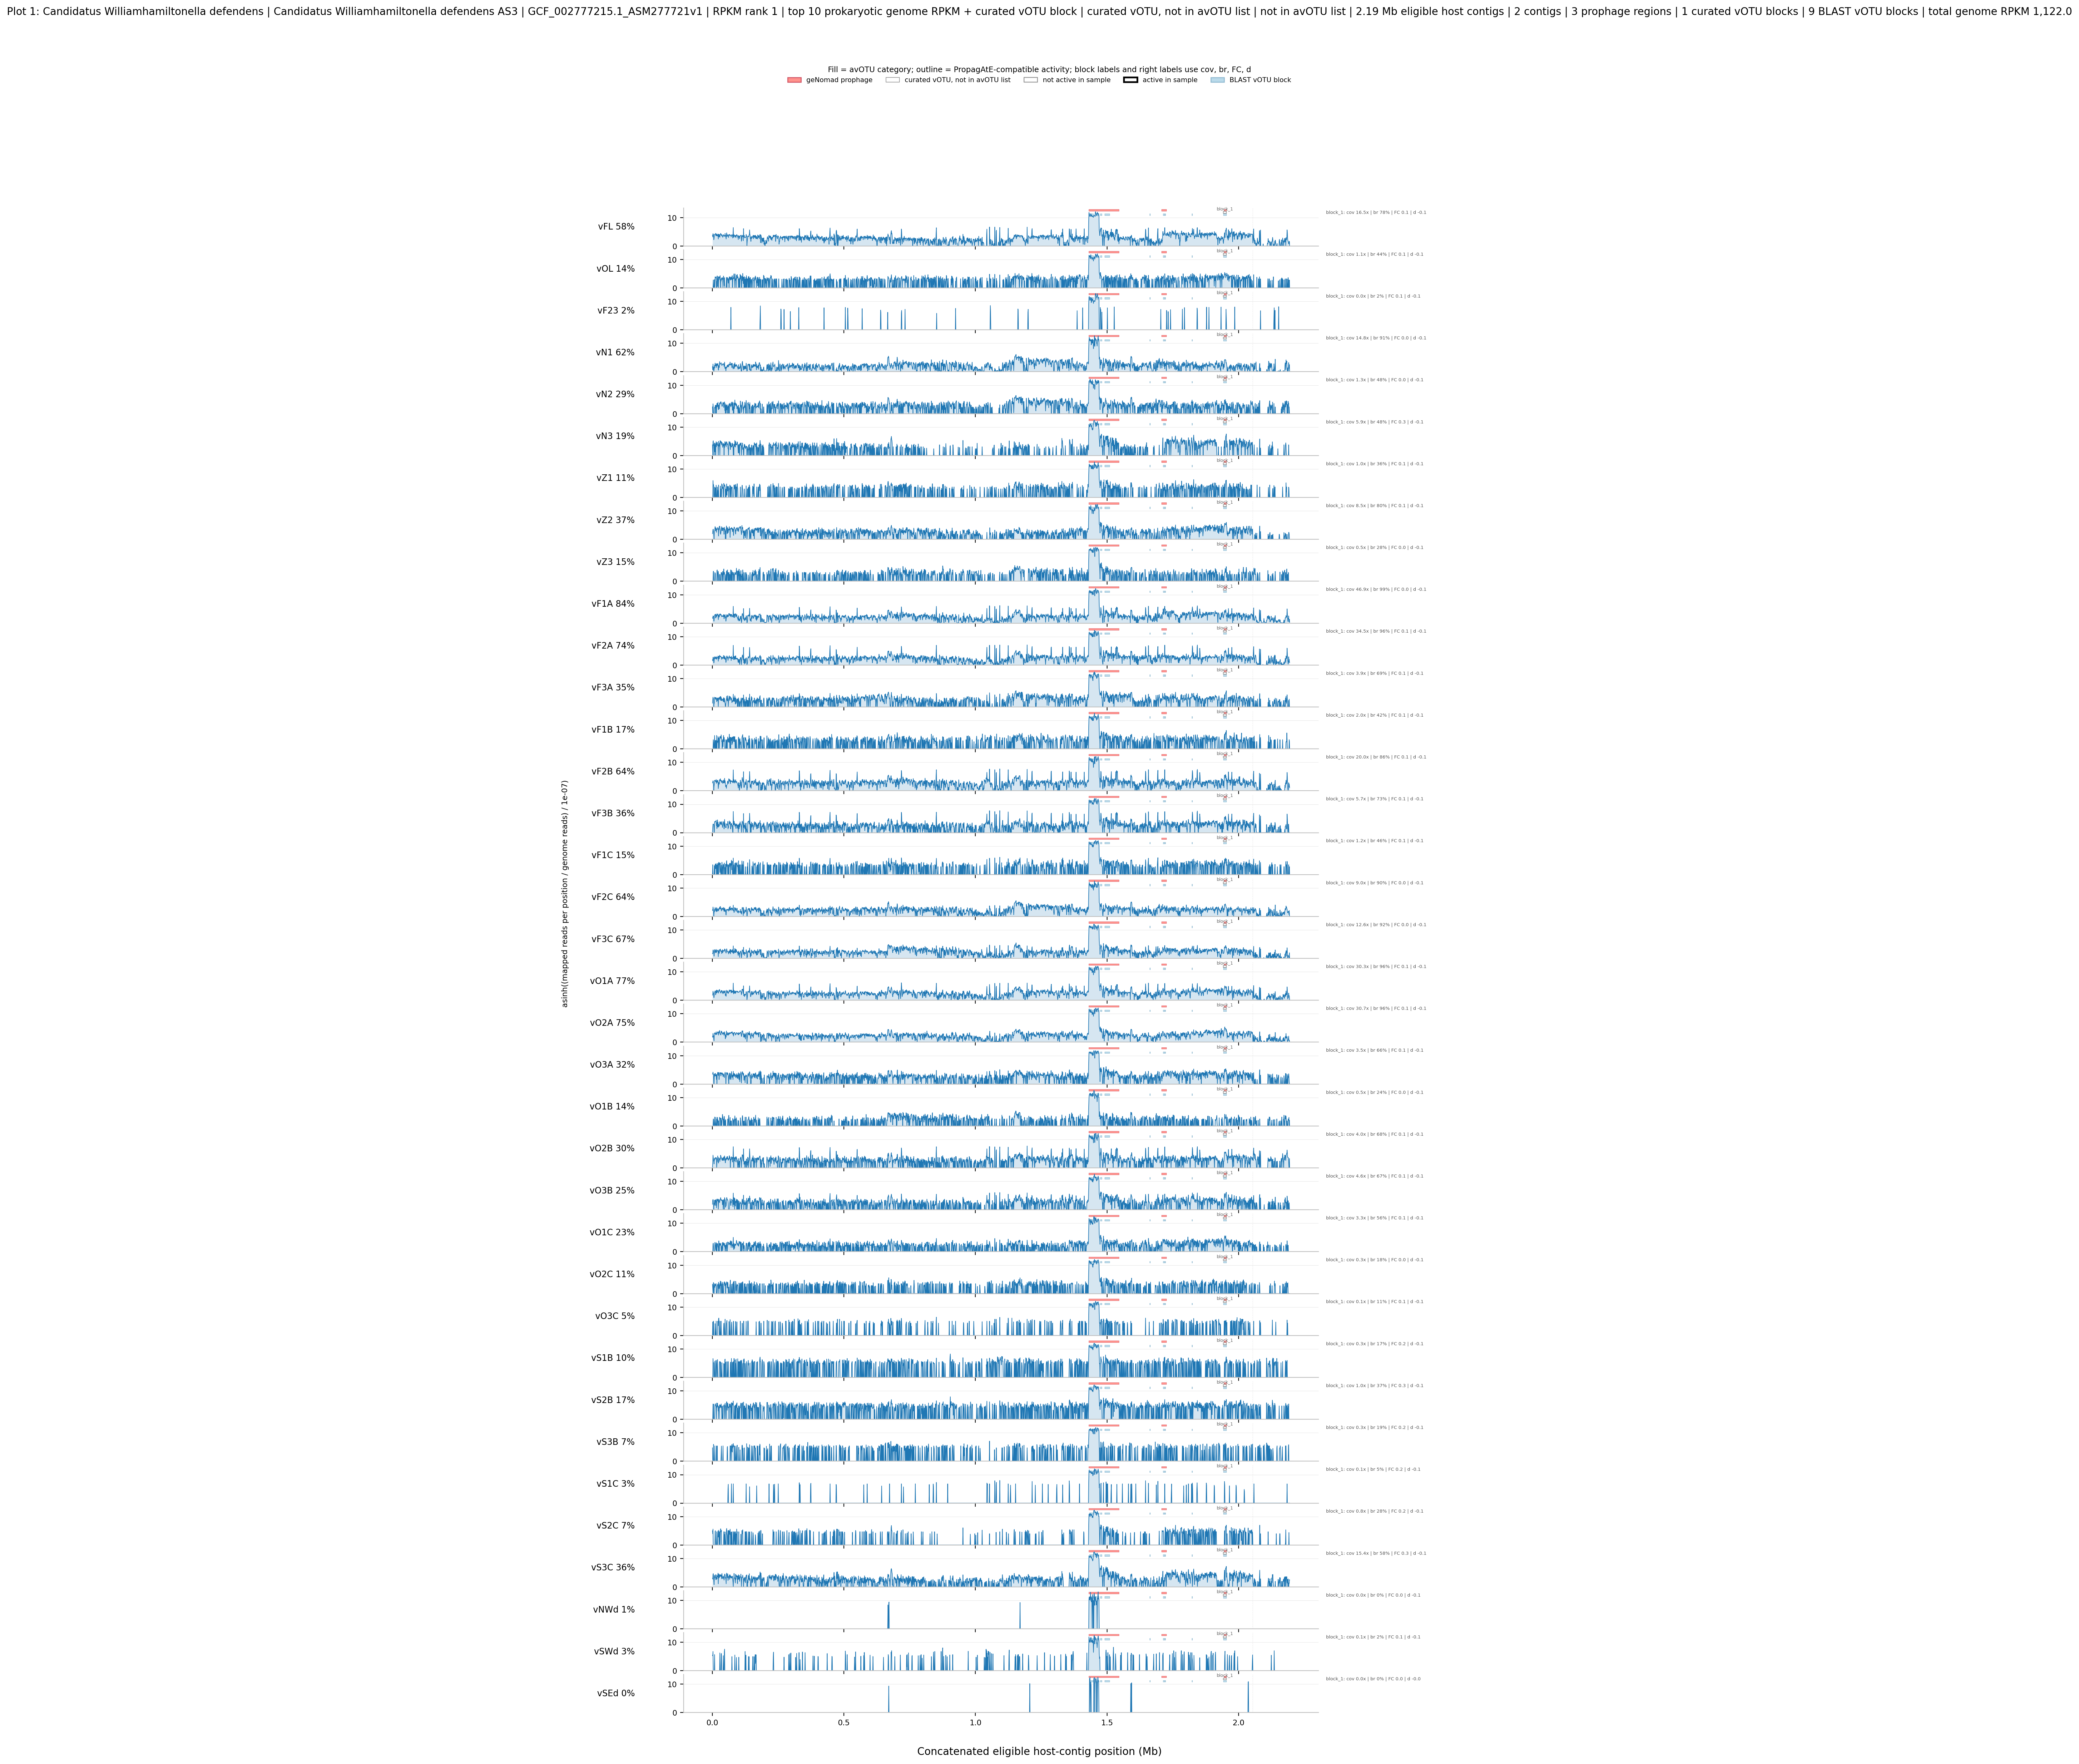

In [12]:
from pathlib import Path
from IPython.display import Image as IPythonImage, SVG, display

# The large 36-sample profiles are opt-in. Turn on MAKE_PER_GENOME_COVERAGE_PLOTS
# in the settings cell before running the workflow to create and show them here.
N_PROFILES_TO_SHOW = 1  # TOP_N_GENOMES
if not MAKE_PER_GENOME_COVERAGE_PLOTS:
    print("Per-genome coverage profiles were skipped. Set MAKE_PER_GENOME_COVERAGE_PLOTS = True to create them.")
elif plot_paths_df.empty:
    print("No per-genome coverage profiles were created.")
else:
    display_columns = [
        column for column in [
            'rank', 'genome', 'file_label', 'rpkm_rank', 'selection_reason',
            'avotu_category', 'active_list_label', 'png', 'svg',
        ] if column in plot_paths_df.columns
    ]
    display(plot_paths_df[display_columns].head(N_PROFILES_TO_SHOW))
    def existing_plot_path(value):
        if pd.isna(value) or not str(value).strip():
            return None
        path = Path(str(value))
        return path if path.exists() else None

    displayed_profile_count = 0
    for _, plot_row in plot_paths_df.head(N_PROFILES_TO_SHOW).iterrows():
        svg_path = existing_plot_path(plot_row.get('svg', ''))
        png_path = existing_plot_path(plot_row.get('png', ''))
        if svg_path is not None:
            display(SVG(filename=str(svg_path)))
            displayed_profile_count += 1
        elif png_path is not None:
            display(IPythonImage(filename=str(png_path)))
            displayed_profile_count += 1
        else:
            print(f"No saved profile image found for {plot_row.get('file_label', plot_row.get('genome', 'profile'))}.")
    if displayed_profile_count == 0:
        print("No profile images were found. Set SAVE_SVG = True or SAVE_PNG = True before rerunning the workflow.")


## Selected vOTU block activity summary


In [13]:
CURATED_LIST_STATUS_ORDER = ["In curated active list", "Not in curated active list"]


def avotu_category_label(category: str) -> str:
    return {
        "unique": "Low overlap/unique avOTU",
        "common": "Common avOTU",
        "core": "Core avOTU",
        "ubiquitous": "Ubiquitous avOTU",
        "non_aVOTU": "Curated vOTU, not in avOTU list",
    }.get(str(category), str(category))


def build_curated_votu_activity_summary(
    votu_block_sample_activity: pd.DataFrame,
    block_active_sample_counts: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    curated_activity = votu_block_sample_activity.loc[
        votu_block_sample_activity["source"].eq("curated_votu_block")
    ].copy()
    curated_blocks = block_active_sample_counts.loc[
        block_active_sample_counts["source"].eq("curated_votu_block")
    ].copy()

    if curated_activity.empty or curated_blocks.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    category_join_columns = [
        "genome", "target_seq", "block_start_1based", "block_end_1based", "source",
    ]
    category_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_votu_blocks.csv"
    if category_path.exists():
        category_annotations = (
            pd.read_csv(category_path)
            .loc[lambda frame: frame["source"].eq("curated_votu_block")]
            .loc[:, category_join_columns + ["avotu_category", "avotu_category_rank"]]
            .drop_duplicates(category_join_columns)
        )

        def add_avotu_category(frame: pd.DataFrame) -> pd.DataFrame:
            if {"avotu_category", "avotu_category_rank"}.issubset(frame.columns):
                return frame
            return frame.merge(category_annotations, on=category_join_columns, how="left")

        curated_activity = add_avotu_category(curated_activity)
        curated_blocks = add_avotu_category(curated_blocks)

    for frame in [curated_activity, curated_blocks]:
        if "avotu_category" not in frame.columns:
            frame["avotu_category"] = NON_AVOTU_CATEGORY
        if "avotu_category_rank" not in frame.columns:
            frame["avotu_category_rank"] = NON_AVOTU_CATEGORY_RANK
        frame["avotu_category"] = frame["avotu_category"].fillna(NON_AVOTU_CATEGORY)
        frame["curated_list_status"] = np.where(
            frame["is_active_votu_from_list"].astype(bool),
            CURATED_LIST_STATUS_ORDER[0],
            CURATED_LIST_STATUS_ORDER[1],
        )
        frame["block_key"] = frame["genome"].astype(str) + "::" + frame["block_index"].astype(str)

    if "activity_status" not in curated_activity.columns:
        curated_activity["activity_status"] = np.where(
            curated_activity["ACTIVE"].astype(bool),
            "ACTIVE",
            "DORMANT",
        )

    curated_blocks["mapping_ACTIVE_in_any_sample"] = curated_blocks["n_samples_ACTIVE"] > 0
    grouped_blocks = (
        curated_blocks
        .groupby(["curated_list_status", "avotu_category"], observed=True, dropna=False)
        .agg(
            n_curated_blocks=("block_key", "size"),
            n_blocks_ACTIVE_in_any_sample=("mapping_ACTIVE_in_any_sample", "sum"),
            median_ACTIVE_samples=("n_samples_ACTIVE", "median"),
            mean_ACTIVE_samples=("n_samples_ACTIVE", "mean"),
            max_ACTIVE_samples=("n_samples_ACTIVE", "max"),
        )
        .reset_index()
    )
    grouped_calls = (
        curated_activity
        .groupby(["curated_list_status", "avotu_category"], observed=True, dropna=False)
        .agg(
            n_block_sample_tests=("block_key", "size"),
            n_ACTIVE_block_sample_calls=("ACTIVE", "sum"),
            n_AMBIGUOUS_block_sample_calls=("activity_status", lambda x: x.eq("AMBIGUOUS").sum()),
            n_DORMANT_block_sample_calls=("activity_status", lambda x: x.eq("DORMANT").sum()),
            n_NOT_PRESENT_block_sample_calls=("activity_status", lambda x: x.eq("NOT_PRESENT").sum()),
        )
        .reset_index()
    )
    summary_index = pd.MultiIndex.from_product(
        [CURATED_LIST_STATUS_ORDER, AVOTU_LEGEND_CATEGORY_ORDER],
        names=["curated_list_status", "avotu_category"],
    )
    summary_by_list_category = (
        pd.DataFrame(index=summary_index)
        .reset_index()
        .merge(grouped_blocks, on=["curated_list_status", "avotu_category"], how="left")
        .merge(grouped_calls, on=["curated_list_status", "avotu_category"], how="left")
    )
    count_columns = [
        "n_curated_blocks", "n_blocks_ACTIVE_in_any_sample", "n_block_sample_tests",
        "n_ACTIVE_block_sample_calls", "n_AMBIGUOUS_block_sample_calls",
        "n_DORMANT_block_sample_calls", "n_NOT_PRESENT_block_sample_calls",
    ]
    summary_by_list_category[count_columns] = (
        summary_by_list_category[count_columns].fillna(0).astype(int)
    )
    summary_by_list_category["pct_blocks_ACTIVE_in_any_sample"] = np.where(
        summary_by_list_category["n_curated_blocks"] > 0,
        100 * summary_by_list_category["n_blocks_ACTIVE_in_any_sample"]
        / summary_by_list_category["n_curated_blocks"],
        np.nan,
    ).round(1)
    summary_by_list_category[["median_ACTIVE_samples", "mean_ACTIVE_samples", "max_ACTIVE_samples"]] = (
        summary_by_list_category[["median_ACTIVE_samples", "mean_ACTIVE_samples", "max_ACTIVE_samples"]].fillna(0).round(1)
    )

    active_calls = curated_activity.loc[curated_activity["ACTIVE"].astype(bool)].copy()
    active_category_counts = (
        active_calls.groupby(["sample", "avotu_category"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=SAMPLES_36, columns=AVOTU_LEGEND_CATEGORY_ORDER, fill_value=0)
    )
    active_list_counts = (
        active_calls.groupby(["sample", "curated_list_status"], observed=True)
        .size()
        .unstack(fill_value=0)
        .reindex(index=SAMPLES_36, columns=CURATED_LIST_STATUS_ORDER, fill_value=0)
    )
    sample_summary = active_category_counts.reset_index(names="sample")
    sample_summary["n_active_curated_blocks"] = active_category_counts.sum(axis=1).to_numpy()
    sample_summary["n_active_blocks_in_curated_active_list"] = active_list_counts[CURATED_LIST_STATUS_ORDER[0]].to_numpy()
    sample_summary["n_active_blocks_not_in_curated_active_list"] = active_list_counts[CURATED_LIST_STATUS_ORDER[1]].to_numpy()

    n_blocks = len(curated_blocks)
    n_active_blocks = int(curated_blocks["mapping_ACTIVE_in_any_sample"].sum())
    n_active_list_blocks = int(curated_blocks["is_active_votu_from_list"].astype(bool).sum())
    overview = pd.DataFrame([
        {"metric": "Curated vOTU blocks", "value": n_blocks},
        {"metric": "Curated vOTU blocks PropagAtE-compatible ACTIVE in >=1 sample", "value": n_active_blocks},
        {"metric": "Percent of curated blocks PropagAtE-compatible ACTIVE in >=1 sample", "value": round(100 * n_active_blocks / n_blocks, 1) if n_blocks else np.nan},
        {"metric": "Total ACTIVE curated block-sample calls", "value": int(curated_activity["ACTIVE"].sum())},
        {"metric": "Curated blocks in the curated active list", "value": n_active_list_blocks},
        {"metric": "Curated blocks not in the curated active list", "value": n_blocks - n_active_list_blocks},
        {"metric": "Samples evaluated", "value": len(SAMPLES_36)},
    ])

    curated_blocks = curated_blocks.sort_values(
        ["n_samples_ACTIVE", "max_fold_change_inside_vs_background", "max_inside_total_bin_mapped_reads"],
        ascending=[False, False, False],
    ).reset_index(drop=True)
    return overview, summary_by_list_category, sample_summary, curated_blocks


def plot_curated_votu_activity_summary(
    curated_blocks: pd.DataFrame,
    sample_summary: pd.DataFrame,
    output_path: Path,
) -> Path | None:
    if curated_blocks.empty:
        return None

    figure = Figure(figsize=(14, 13))
    grid = figure.add_gridspec(2, 2, height_ratios=[1.0, 2.7], hspace=0.48, wspace=0.30)
    status_axes = [
        figure.add_subplot(grid[0, 0]),
        figure.add_subplot(grid[0, 1]),
    ]
    sample_axis = figure.add_subplot(grid[1, :])
    rng = np.random.default_rng(17)
    category_positions = np.arange(len(AVOTU_LEGEND_CATEGORY_ORDER))

    for axis, status in zip(status_axes, CURATED_LIST_STATUS_ORDER):
        status_blocks = curated_blocks.loc[curated_blocks["curated_list_status"].eq(status)]
        for position, category in enumerate(AVOTU_LEGEND_CATEGORY_ORDER):
            subset = status_blocks.loc[status_blocks["avotu_category"].eq(category)]
            if not subset.empty:
                y_values = position + rng.uniform(-0.12, 0.12, size=len(subset))
                axis.scatter(
                    subset["n_samples_ACTIVE"],
                    y_values,
                    s=30,
                    facecolor=AVOTU_CATEGORY_COLORS[category],
                    edgecolor="#1a1a1a",
                    linewidth=0.45,
                    alpha=0.88,
                    zorder=3,
                )
            axis.text(
                len(SAMPLES_36) + 0.45,
                position,
                f"n={len(subset)}",
                va="center",
                ha="left",
                fontsize=8,
                color="#3d3d3d",
            )
        axis.set_title(status, fontsize=11, pad=8)
        axis.set_xlim(-0.5, len(SAMPLES_36) + 5.4)
        axis.set_xticks(np.arange(0, len(SAMPLES_36) + 1, 6))
        axis.set_xlabel("Number of the 36 samples where block is ACTIVE")
        axis.set_yticks(category_positions)
        axis.set_yticklabels([avotu_category_label(category) for category in AVOTU_LEGEND_CATEGORY_ORDER])
        axis.invert_yaxis()
        axis.grid(axis="x", color="#d9d9d9", linewidth=0.7, zorder=0)
        axis.spines[["top", "right"]].set_visible(False)

    sample_plot = sample_summary.sort_values(
        ["n_active_curated_blocks", "sample"],
        ascending=[False, True],
        kind="stable",
    ).reset_index(drop=True)
    y_positions = np.arange(len(sample_plot))
    left = np.zeros(len(sample_plot))
    for category in AVOTU_LEGEND_CATEGORY_ORDER:
        values = sample_plot[category].to_numpy()
        sample_axis.barh(
            y_positions,
            values,
            left=left,
            height=0.72,
            color=AVOTU_CATEGORY_COLORS[category],
            edgecolor="#2f2f2f",
            linewidth=0.25,
        )
        left += values
    total_offset = max(0.25, 0.02 * max(1, int(left.max())))
    for y_position, total in zip(y_positions, left):
        sample_axis.text(total + total_offset, y_position, str(int(total)), va="center", ha="left", fontsize=8)
    sample_axis.set_yticks(y_positions)
    sample_axis.set_yticklabels(sample_plot["sample"].astype(str))
    sample_axis.invert_yaxis()
    sample_axis.set_xlabel("Number of curated vOTU blocks called ACTIVE in each sample")
    sample_axis.set_title("Active curated vOTU blocks per sample", fontsize=11, pad=8)
    sample_axis.grid(axis="x", color="#d9d9d9", linewidth=0.7, zorder=0)
    sample_axis.spines[["top", "right"]].set_visible(False)
    sample_axis.set_xlim(0, max(1, int(left.max())) + max(1.8, total_offset * 7))

    legend_handles = [
        Patch(
            facecolor=AVOTU_CATEGORY_COLORS[category],
            edgecolor="#2f2f2f",
            label=avotu_category_label(category),
        )
        for category in AVOTU_LEGEND_CATEGORY_ORDER
    ]
    figure.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=5,
        frameon=False,
        fontsize=8,
        title="Fill color: avOTU category",
        title_fontsize=9,
    )
    figure.suptitle("Curated vOTU block activity across the 36 samples", fontsize=14, y=0.995)
    figure.subplots_adjust(left=0.19, right=0.98, bottom=0.055, top=0.84)
    figure.savefig(output_path, format="svg", bbox_inches="tight")
    plt.close(figure)
    return output_path


(
    curated_votu_activity_overview,
    curated_votu_activity_by_list_category,
    curated_votu_activity_by_sample,
    curated_votu_block_activity_summary,
) = build_curated_votu_activity_summary(
    combined_votu_block_sample_activity,
    votu_block_activity_sample_counts,
)

CURATED_VOTU_ACTIVITY_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_summary.svg"
CURATED_VOTU_ACTIVITY_OVERVIEW_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_overview.csv"
CURATED_VOTU_ACTIVITY_BY_CATEGORY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_by_list_and_category.csv"
CURATED_VOTU_ACTIVITY_BY_SAMPLE_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_by_sample.csv"
CURATED_VOTU_BLOCK_ACTIVITY_SUMMARY_PATH = OUTPUT_DIR / f"{OUTPUT_PREFIX}_curated_votu_block_activity_summary.csv"

curated_votu_activity_overview.to_csv(CURATED_VOTU_ACTIVITY_OVERVIEW_PATH, index=False)
curated_votu_activity_by_list_category.to_csv(CURATED_VOTU_ACTIVITY_BY_CATEGORY_PATH, index=False)
curated_votu_activity_by_sample.to_csv(CURATED_VOTU_ACTIVITY_BY_SAMPLE_PATH, index=False)
curated_votu_block_activity_summary.to_csv(CURATED_VOTU_BLOCK_ACTIVITY_SUMMARY_PATH, index=False)
curated_votu_activity_summary_figure = plot_curated_votu_activity_summary(
    curated_votu_block_activity_summary,
    curated_votu_activity_by_sample,
    CURATED_VOTU_ACTIVITY_SUMMARY_PATH,
)
print(f"Saved curated vOTU activity summary figure: {curated_votu_activity_summary_figure}")


Saved curated vOTU activity summary figure: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_votu_blocks_top10_rpkm_plus_votu_block_genomes_curated_votu_block_activity_summary.svg


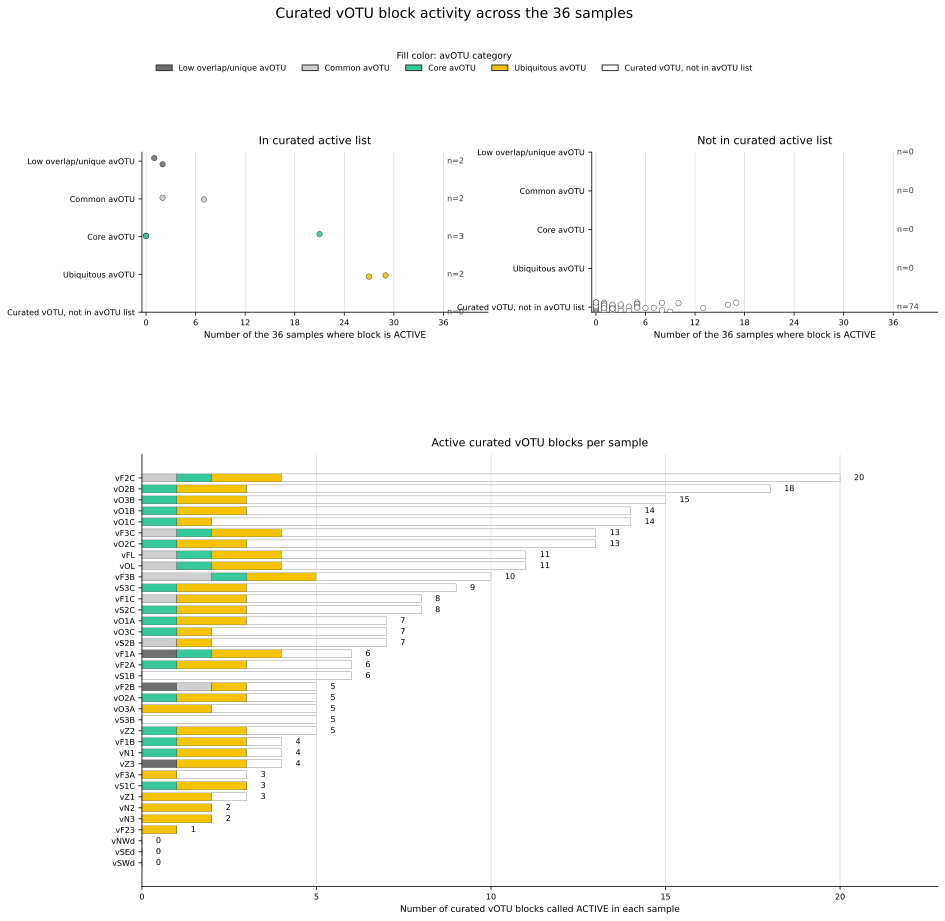

In [14]:
from IPython.display import SVG, display

display(SVG(filename=str(CURATED_VOTU_ACTIVITY_SUMMARY_PATH)))


## PropagAtE-style vOTU labels for rank-abundance comparison

09 selects one bacterial region per vOTU after the `>=100 kb` host-contig and
`<80%` geNomad viral-coverage filters, shared clustering, and direct reciprocal
95/85/85 support. Here, that exact selected region receives a PropagAtE-style
label from the 36 samples. A vOTU is `propagate_active` when its selected block is
ACTIVE in at least one sample.

The resulting table is the only activity-label input used in 11.


In [15]:
# Write one explicit PropagAtE-style label for every vOTU selected by 09.
# The label table is the hand-off to 11; it does not use any earlier activity table.
PROPAGATE_VOTU_LABELS_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_propagate_votu_labels.csv'
PROPAGATE_VOTU_LABEL_SUMMARY_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_propagate_votu_label_summary.csv'
VOTU_RECORDS_OUTPUT_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_votu_records.csv'
VOTU_BLOCKS_OUTPUT_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_votu_blocks.csv'
VOTU_ACTIVITY_OUTPUT_PATH = OUTPUT_DIR / f'{OUTPUT_PREFIX}_votu_block_sample_activity.csv'

for required_path in [
    VOTU_BLOCKS_PATH,
    VOTU_RECORDS_OUTPUT_PATH,
    VOTU_BLOCKS_OUTPUT_PATH,
    VOTU_ACTIVITY_OUTPUT_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            f'Missing required 09/10 activity-label input: {required_path}'
        )


def parse_boolean(series, name):
    parsed = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            'true': True, 't': True, '1': True, 'yes': True, 'y': True,
            'false': False, 'f': False, '0': False, 'no': False, 'n': False,
        })
    )
    if parsed.isna().any():
        examples = series.loc[parsed.isna()].head(5).tolist()
        raise ValueError(f'Could not parse {name} as boolean: {examples}')
    return parsed.astype(bool)


def activity_block_key(frame, active_column):
    return (
        frame['genome'].astype(str).str.strip()
        + '::' + frame['target_seq'].astype(str).str.strip()
        + '::' + pd.to_numeric(frame['block_start_1based'], errors='raise').astype(int).astype(str)
        + '-' + pd.to_numeric(frame['block_end_1based'], errors='raise').astype(int).astype(str)
        + '::' + np.where(frame[active_column].astype(bool), 'in_avotu_list', 'not_in_avotu_list')
    )


s02_selected = pd.read_csv(VOTU_BLOCKS_PATH)
records = pd.read_csv(VOTU_RECORDS_OUTPUT_PATH)
blocks = pd.read_csv(VOTU_BLOCKS_OUTPUT_PATH)
activity = pd.read_csv(VOTU_ACTIVITY_OUTPUT_PATH)

required_s02_columns = {'qseqid', 'sseqid', 'start', 'end'}
s02_length_column = next(
    (column for column in ['host_contig_length', 'sseqid_len', 'sequence_length']
     if column in s02_selected.columns),
    None,
)
s02_viral_fraction_column = next(
    (column for column in ['host_contig_geNomad_viral_fraction', 'geNomad_viral_fraction']
     if column in s02_selected.columns),
    None,
)
if s02_length_column is None or s02_viral_fraction_column is None:
    raise ValueError(
        '09 selected vOTU blocks must include host-contig length and merged '
        'geNomad viral-fraction columns.'
    )
s02_selected['host_contig_length'] = pd.to_numeric(
    s02_selected[s02_length_column], errors='raise'
)
s02_selected['host_contig_geNomad_viral_fraction'] = pd.to_numeric(
    s02_selected[s02_viral_fraction_column], errors='raise'
)

required_record_columns = {
    'qseqid', 'genome', 'sseqid', 'target_start_1based',
    'target_end_1based', 'source', 'is_active_votu',
}
required_block_columns = {
    'genome', 'target_seq', 'block_start_1based', 'block_end_1based',
    'source', 'is_active_votu',
}
required_activity_columns = {
    'genome', 'sample', 'target_seq', 'block_start_1based',
    'block_end_1based', 'source', 'is_active_votu_from_list', 'ACTIVE',
    'activity_status', 'block_mean_coverage', 'block_coverage_breadth',
    'fold_change_inside_vs_background', 'cohen_d_inside_vs_background',
}
for table_name, frame, required_columns in [
    ('09 selected vOTU blocks', s02_selected, required_s02_columns),
    ('10 vOTU records', records, required_record_columns),
    ('10 vOTU blocks', blocks, required_block_columns),
    ('10 vOTU block/sample activity', activity, required_activity_columns),
]:
    missing_columns = sorted(required_columns - set(frame.columns))
    if missing_columns:
        raise ValueError(f'{table_name} is missing required columns: {missing_columns}')

s02_selected['qseqid'] = s02_selected['qseqid'].astype(str).str.strip()
s02_selected['sseqid'] = s02_selected['sseqid'].astype(str).str.strip()
s02_selected['selected_start_1based'] = pd.to_numeric(
    s02_selected[['start', 'end']].min(axis=1), errors='raise'
).astype(int)
s02_selected['selected_end_1based'] = pd.to_numeric(
    s02_selected[['start', 'end']].max(axis=1), errors='raise'
).astype(int)
if s02_selected['qseqid'].duplicated().any():
    duplicates = s02_selected.loc[s02_selected['qseqid'].duplicated(), 'qseqid'].head(5).tolist()
    raise ValueError(f'09 must select one region per vOTU; duplicates: {duplicates}')
if (s02_selected['host_contig_length'] < MIN_REFERENCE_CONTIG_LENGTH).any():
    raise ValueError('An 09-selected vOTU region is on a host contig below the 100 kb filter.')
if (s02_selected['host_contig_geNomad_viral_fraction'] >= MAX_REFERENCE_CONTIG_GENOMAD_VIRAL_FRACTION).any():
    raise ValueError('An 09-selected vOTU region is on a host contig at or above 80% geNomad viral coverage.')

records = records.loc[records['source'].eq('curated_votu_block')].copy()
blocks = blocks.loc[blocks['source'].eq('curated_votu_block')].copy()
activity = activity.loc[
    activity['source'].eq('curated_votu_block') & activity['sample'].isin(SAMPLES_36)
].copy()
if records.empty or blocks.empty or activity.empty:
    raise ValueError('No curated 10 vOTU records, blocks, or activity rows were found.')

records['qseqid'] = records['qseqid'].astype(str).str.strip()
records['sseqid'] = records['sseqid'].astype(str).str.strip()
records['target_start_1based'] = pd.to_numeric(records['target_start_1based'], errors='raise').astype(int)
records['target_end_1based'] = pd.to_numeric(records['target_end_1based'], errors='raise').astype(int)
records['is_active_votu'] = parse_boolean(records['is_active_votu'], '10 record active-list membership')

blocks['target_seq'] = blocks['target_seq'].astype(str).str.strip()
blocks['is_active_votu'] = parse_boolean(blocks['is_active_votu'], '10 block active-list membership')
blocks['block_key'] = activity_block_key(blocks, 'is_active_votu')
if blocks['block_key'].duplicated().any():
    duplicates = blocks.loc[blocks['block_key'].duplicated(), 'block_key'].head(5).tolist()
    raise ValueError(f'10 curated display-block keys are not unique: {duplicates}')

activity['target_seq'] = activity['target_seq'].astype(str).str.strip()
activity['is_active_votu_from_list'] = parse_boolean(
    activity['is_active_votu_from_list'], '10 activity active-list membership'
)
activity['ACTIVE'] = parse_boolean(activity['ACTIVE'], '10 ACTIVE calls')
activity['block_key'] = activity_block_key(activity, 'is_active_votu_from_list')
if activity.duplicated(['block_key', 'sample']).any():
    raise ValueError('10 activity table has duplicate block/sample rows.')

observed_samples = activity.groupby('block_key')['sample'].agg(lambda values: set(values))
expected_samples = set(SAMPLES_36)
incomplete_blocks = observed_samples.loc[observed_samples.ne(expected_samples)]
if not incomplete_blocks.empty:
    raise ValueError(
        'Each curated 10 block must have one activity row for all 36 samples; '
        f'incomplete blocks include: {incomplete_blocks.index[:5].tolist()}'
    )

# First assign every selected 09 region to its exact 10 curated record.
records_for_join = records.rename(columns={
    'target_start_1based': 'selected_start_1based',
    'target_end_1based': 'selected_end_1based',
    'is_active_votu': 'in_avotu_list',
    'genome': 'record_genome',
})
record_columns = [
    'qseqid', 'sseqid', 'selected_start_1based', 'selected_end_1based',
    'record_genome', 'in_avotu_list', 'avotu_category', 'avotu_category_rank',
]
selected_records = s02_selected.merge(
    records_for_join[record_columns],
    on=['qseqid', 'sseqid', 'selected_start_1based', 'selected_end_1based'],
    how='left',
    validate='one_to_one',
)
if selected_records['record_genome'].isna().any():
    missing = selected_records.loc[selected_records['record_genome'].isna(), 'qseqid'].head(5).tolist()
    raise ValueError(f'09-selected vOTUs missing from 10 curated records: {missing}')
if not selected_records['genome'].eq(selected_records['record_genome']).all():
    mismatches = selected_records.loc[
        ~selected_records['genome'].eq(selected_records['record_genome']),
        ['qseqid', 'genome', 'record_genome'],
    ].head(5).to_dict('records')
    raise ValueError(f'09/10 genome assignments disagree: {mismatches}')

# Then assign that exact record to the display block that received the per-sample call.
block_matches = selected_records.merge(
    blocks[
        [
            'block_key', 'genome', 'target_seq', 'block_start_1based',
            'block_end_1based', 'is_active_votu',
        ]
    ],
    left_on=['genome', 'sseqid', 'in_avotu_list'],
    right_on=['genome', 'target_seq', 'is_active_votu'],
    how='left',
)
block_matches = block_matches.loc[
    (block_matches['selected_start_1based'] >= block_matches['block_start_1based'])
    & (block_matches['selected_end_1based'] <= block_matches['block_end_1based'])
].copy()
match_counts = block_matches.groupby('qseqid')['block_key'].nunique()
missing_matches = sorted(set(s02_selected['qseqid']) - set(match_counts.index))
ambiguous_matches = match_counts.loc[match_counts.ne(1)]
if missing_matches or not ambiguous_matches.empty:
    raise ValueError(
        'Every 09-selected vOTU must map to one 10 curated display block; '
        f'missing={missing_matches[:5]}, ambiguous={ambiguous_matches.head().to_dict()}'
    )
selected_to_block = selected_records.merge(
    block_matches[['qseqid', 'block_key']].drop_duplicates(),
    on='qseqid',
    how='inner',
    validate='one_to_one',
)

active_samples = (
    activity.loc[activity['ACTIVE']]
    .groupby('block_key')['sample']
    .agg(lambda values: ', '.join(sorted(values.astype(str))))
)
block_activity_summary = (
    activity.groupby('block_key', as_index=False)
    .agg(
        n_samples_evaluated=('sample', 'nunique'),
        n_samples_ACTIVE=('ACTIVE', 'sum'),
        n_samples_AMBIGUOUS=('activity_status', lambda values: values.eq('AMBIGUOUS').sum()),
        n_samples_DORMANT=('activity_status', lambda values: values.eq('DORMANT').sum()),
        n_samples_NOT_PRESENT=('activity_status', lambda values: values.eq('NOT_PRESENT').sum()),
        max_block_mean_coverage=('block_mean_coverage', 'max'),
        max_block_coverage_breadth=('block_coverage_breadth', 'max'),
        max_fold_change_inside_vs_background=('fold_change_inside_vs_background', 'max'),
        max_cohen_d_inside_vs_background=('cohen_d_inside_vs_background', 'max'),
    )
    .merge(active_samples.rename('ACTIVE_samples'), on='block_key', how='left')
)
block_activity_summary['ACTIVE_samples'] = block_activity_summary['ACTIVE_samples'].fillna('')

propagate_votu_labels = selected_to_block.merge(
    block_activity_summary,
    on='block_key',
    how='left',
    validate='many_to_one',
)
if propagate_votu_labels['n_samples_evaluated'].isna().any():
    missing = propagate_votu_labels.loc[
        propagate_votu_labels['n_samples_evaluated'].isna(), 'qseqid'
    ].head(5).tolist()
    raise ValueError(f'09-selected vOTUs missing 10 activity summaries: {missing}')
if not propagate_votu_labels['n_samples_evaluated'].eq(len(SAMPLES_36)).all():
    raise ValueError('At least one selected vOTU does not have 36 evaluated samples.')

propagate_votu_labels['propagate_active'] = propagate_votu_labels['n_samples_ACTIVE'].gt(0)
propagate_votu_labels['vOTU'] = propagate_votu_labels['qseqid']
propagate_votu_labels['activity_rule'] = (
    f'ACTIVE in >=1 of {len(SAMPLES_36)} samples: mean coverage >= '
    f'{VOTU_REGION_ACTIVE_MIN_MEAN_COVERAGE:g}, breadth >= '
    f'{VOTU_REGION_ACTIVE_MIN_BREADTH:.0%}, fold change >= '
    f'{VOTU_REGION_ACTIVE_MIN_FOLD_CHANGE:g}, Cohen d >= '
    f'{VOTU_REGION_ACTIVE_MIN_COHEN_D:g}'
)

first_columns = [
    'vOTU', 'qseqid', 'propagate_active', 'n_samples_ACTIVE', 'ACTIVE_samples',
    'n_samples_evaluated', 'n_samples_AMBIGUOUS', 'n_samples_DORMANT',
    'n_samples_NOT_PRESENT', 'genome', 'sseqid', 'selected_start_1based',
    'selected_end_1based', 'block_start_1based', 'block_end_1based',
    'in_avotu_list', 'avotu_category', 'avotu_category_rank',
    'host_contig_length', 'host_contig_geNomad_viral_fraction',
    'max_block_mean_coverage', 'max_block_coverage_breadth',
    'max_fold_change_inside_vs_background', 'max_cohen_d_inside_vs_background',
    'activity_rule',
]
first_columns = [column for column in first_columns if column in propagate_votu_labels.columns]
remaining_columns = [
    column for column in propagate_votu_labels.columns if column not in first_columns
]
propagate_votu_labels = (
    propagate_votu_labels[first_columns + remaining_columns]
    .sort_values(['propagate_active', 'n_samples_ACTIVE', 'vOTU'], ascending=[False, False, True])
    .reset_index(drop=True)
)
if propagate_votu_labels['vOTU'].duplicated().any() or len(propagate_votu_labels) != len(s02_selected):
    raise ValueError('The final 10 PropagAtE-style label table is not one row per 09-selected vOTU.')

propagate_votu_label_summary = (
    propagate_votu_labels
    .groupby(['propagate_active', 'in_avotu_list', 'avotu_category'], dropna=False, as_index=False)
    .agg(
        n_vOTUs=('vOTU', 'nunique'),
        median_ACTIVE_samples=('n_samples_ACTIVE', 'median'),
        max_ACTIVE_samples=('n_samples_ACTIVE', 'max'),
    )
    .sort_values(['propagate_active', 'avotu_category'], ascending=[False, True])
    .reset_index(drop=True)
)
propagate_votu_labels.to_csv(PROPAGATE_VOTU_LABELS_PATH, index=False)
propagate_votu_label_summary.to_csv(PROPAGATE_VOTU_LABEL_SUMMARY_PATH, index=False)

print(f'09-selected vOTUs labelled: {len(propagate_votu_labels)}')
print(f'PropagAtE-style active in >=1 sample: {int(propagate_votu_labels["propagate_active"].sum())}')
print(f'Saved 10 PropagAtE-style labels: {PROPAGATE_VOTU_LABELS_PATH}')
print(f'Saved 10 label summary: {PROPAGATE_VOTU_LABEL_SUMMARY_PATH}')


09-selected vOTUs labelled: 86
PropagAtE-style active in >=1 sample: 48
Saved 10 PropagAtE-style labels: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_votu_blocks_top10_rpkm_plus_votu_block_genomes_propagate_votu_labels.csv
Saved 10 label summary: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/10_vOTU_block_activity/strain_depth_profiles/10_votu_blocks_top10_rpkm_plus_votu_block_genomes_propagate_votu_label_summary.csv


In [16]:
display(propagate_votu_label_summary)
display(propagate_votu_labels.head(20))


,propagate_active,in_avotu_list,avotu_category,n_vOTUs,median_ACTIVE_samples,max_ACTIVE_samples
0,True,True,common,2,4.5,7
1,True,True,core,1,21.0,21
2,True,False,non_aVOTU,40,2.0,17
3,True,True,ubiquitous,3,27.0,29
4,True,True,unique,2,1.5,2
5,False,True,core,2,0.0,0
6,False,False,non_aVOTU,36,0.0,0


,vOTU,qseqid,propagate_active,n_samples_ACTIVE,ACTIVE_samples,n_samples_evaluated,n_samples_AMBIGUOUS,n_samples_DORMANT,n_samples_NOT_PRESENT,genome,...,max_host_genome_breadth,max_host_rpkm,total_host_read_count,n_host_samples,has_direct_pairwise_ani,direct_ani_support,contig_coverage_rank_within_vOTU,selection_rule,record_genome,block_key
0,E_aphidicola_Z9_3_pp3_cluster_15,E_aphidicola_Z9_3_pp3_cluster_15,True,29,"vF1A, vF1B, vF1C, vF23, vF2A, vF2B, vF2C, vF3A...",36,0,5,2,Erwinia_aphidicola_B09_9,...,0.993801,105.363310,105646909.0,36,True,87.151500,1,"eligible host contig >= 100,000 bp with geNoma...",Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9::Erwinia_aphidicola_B...
1,E_aphidicola_W09_2_pp1_cluster_11,E_aphidicola_W09_2_pp1_cluster_11,True,27,"vF1A, vF1B, vF1C, vF2A, vF2C, vF3B, vF3C, vFL,...",36,0,9,0,Erwinia_aphidicola_B09_9,...,0.993801,105.363310,105646909.0,36,True,99.990000,1,"eligible host contig >= 100,000 bp with geNoma...",Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9::Erwinia_aphidicola_B...
2,E_aphidicola_W09_5_pp2_cluster_12,E_aphidicola_W09_5_pp2_cluster_12,True,27,"vF1A, vF1B, vF1C, vF2A, vF2C, vF3B, vF3C, vFL,...",36,0,9,0,Erwinia_aphidicola_B09_9,...,0.993801,105.363310,105646909.0,36,True,99.980000,1,"eligible host contig >= 100,000 bp with geNoma...",Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9::Erwinia_aphidicola_B...
3,vS2B_70_NODE_357_length_20787_cov_124.630619,vS2B_70_NODE_357_length_20787_cov_124.630619,True,21,"vF1A, vF1B, vF2A, vF2C, vF3B, vF3C, vFL, vN1, ...",36,0,15,0,Erwinia_aphidicola_B09_9,...,0.993801,105.363310,105646909.0,36,True,98.624320,1,"eligible host contig >= 100,000 bp with geNoma...",Erwinia_aphidicola_B09_9,Erwinia_aphidicola_B09_9::Erwinia_aphidicola_B...
4,E_aphidicola_W06_8_pp1_cluster_9,E_aphidicola_W06_8_pp1_cluster_9,True,17,"vF1A, vF1C, vF2A, vF2C, vF3C, vN1, vO1C, vO2B,...",36,5,12,2,GCF_014838835.1_ASM1483883v1,...,0.803266,16.508677,767945.0,36,True,99.790000,1,"eligible host contig >= 100,000 bp with geNoma...",GCF_014838835.1_ASM1483883v1,GCF_014838835.1_ASM1483883v1::NZ_JACYMQ0100000...
5,P_poae_B12_7_pp1_cluster_23,P_poae_B12_7_pp1_cluster_23,True,16,"vF2A, vF2B, vF2C, vF3B, vF3C, vFL, vO1A, vO1B,...",36,11,8,1,Pseudomonas_poae_W12_10,...,0.960571,7.005136,8894295.0,36,True,99.990000,1,"eligible host contig >= 100,000 bp with geNoma...",Pseudomonas_poae_W12_10,Pseudomonas_poae_W12_10::Pseudomonas_poae_W12_...
6,vF1aB_50_NODE_429_length_11771_cov_44.268010,vF1aB_50_NODE_429_length_11771_cov_44.268010,True,13,"vF1B, vF2A, vF2C, vF3A, vFL, vO1A, vO1B, vO1C,...",36,11,5,7,GCF_004343105.1_ASM434310v1,...,0.128399,1.780304,57152.0,35,True,96.640000,1,"eligible host contig >= 100,000 bp with geNoma...",GCF_004343105.1_ASM434310v1,GCF_004343105.1_ASM434310v1::NZ_SLYF01000009.1...
7,P_poae_Z9_4_pp1_cluster_25,P_poae_Z9_4_pp1_cluster_25,True,10,"vF2C, vF3C, vFL, vO1A, vO1B, vO2B, vO2C, vO3B,...",36,15,10,1,Pseudomonas_poae_Z9_2,...,0.958564,6.903770,8623114.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma...",Pseudomonas_poae_Z9_2,Pseudomonas_poae_Z9_2::Pseudomonas_poae_Z9_2_1...
8,vS3C_NODE_529_length_11572_cov_28.177129,vS3C_NODE_529_length_11572_cov_28.177129,True,9,"vF3A, vF3C, vO1C, vS1B, vS2B, vS2C, vS3B, vS3C...",36,14,6,7,GCF_014839105.1_ASM1483910v1,...,0.946401,3.434492,1058672.0,34,True,98.990910,1,"eligible host contig >= 100,000 bp with geNoma...",GCF_014839105.1_ASM1483910v1,GCF_014839105.1_ASM1483910v1::NZ_JACYND0100000...
9,P_trivialis_B08_3_pp1_cluster_27,P_trivialis_B08_3_pp1_cluster_27,True,8,"vF2C, vF3C, vO1B, vO1C, vO2B, vO2C, vO3B, vS2C",36,19,8,1,Pseudomonas_trivialis_B08_3,...,0.943220,2.321629,2447924.0,36,True,100.000000,1,"eligible host contig >= 100,000 bp with geNoma...",Pseudomonas_trivialis_B08_3,Pseudomonas_trivialis_B08_3::Pseudomonas_trivi...


## vOTU block input


In [17]:
from IPython.display import display

s02_blocks = pd.read_csv(VOTU_BLOCKS_PATH)
s02_input_summary = pd.DataFrame([{
    'selected vOTU blocks': len(s02_blocks),
    'vOTUs': s02_blocks['qseqid'].nunique(),
    'bacterial reference genomes': s02_blocks['genome'].nunique(),
    'median maximum host breadth (%)': 100 * s02_blocks['max_host_genome_breadth'].median(),
}]).round(1)
display(s02_input_summary)
display(s02_blocks.head())


,selected vOTU blocks,vOTUs,bacterial reference genomes,median maximum host breadth (%)
0,86,86,65,84.8


,qseqid,sseqid_long,cluster_representative,cluster_member_count,selection_evidence,sseqid,start,end,len,n_source_vOTUs,...,total_contig_read_count,n_contig_samples_with_reads,max_host_genome_breadth,max_host_rpkm,total_host_read_count,n_host_samples,has_direct_pairwise_ani,direct_ani_support,contig_coverage_rank_within_vOTU,selection_rule
0,E_aphidicola_N2_3_pp2_cluster_14,NZ_JBBCRR010000007.1_93670_123445,E_aphidicola_N2_3_pp2_cluster_14,2,full vOTU and bacterial region in the same vOT...,NZ_JBBCRR010000007.1,93670,123445,29776,1,...,210198.0,35,0.848036,6.572516,5931510.0,36,True,88.434704,1,"eligible host contig >= 100,000 bp with geNoma..."
1,E_aphidicola_W06_8_pp1_cluster_9,NZ_JACYMQ010000003.1_6330_22357,NZ_JACYMQ010000003.1_6330_22357,2,full vOTU and bacterial region in the same vOT...,NZ_JACYMQ010000003.1,6330,22357,16028,1,...,167347.0,35,0.803266,16.508677,767945.0,36,True,99.790000,1,"eligible host contig >= 100,000 bp with geNoma..."
2,E_aphidicola_W09_2_pp1_cluster_11,Erwinia_aphidicola_B09_9_1_1333823_1381242,E_aphidicola_W09_2_pp1_cluster_11,2,full vOTU and bacterial region in the same vOT...,Erwinia_aphidicola_B09_9_1,1333823,1381242,47420,1,...,105646909.0,36,0.993801,105.363310,105646909.0,36,True,99.990000,1,"eligible host contig >= 100,000 bp with geNoma..."
3,E_aphidicola_W09_5_pp2_cluster_12,Erwinia_aphidicola_B09_9_1_1381285_1423063,E_aphidicola_W09_5_pp2_cluster_12,2,full vOTU and bacterial region in the same vOT...,Erwinia_aphidicola_B09_9_1,1381285,1423063,41779,1,...,105646909.0,36,0.993801,105.363310,105646909.0,36,True,99.980000,1,"eligible host contig >= 100,000 bp with geNoma..."
4,E_aphidicola_Z9_3_pp3_cluster_15,Erwinia_aphidicola_B09_9_1_2327952_2368708,E_aphidicola_Z9_3_pp3_cluster_15,2,full vOTU and bacterial region in the same vOT...,Erwinia_aphidicola_B09_9_1,2327952,2368708,40757,1,...,105646909.0,36,0.993801,105.363310,105646909.0,36,True,87.151500,1,"eligible host contig >= 100,000 bp with geNoma..."
